In [1709]:
import numpy as np
import pylab as plt
import scipy as sp
import pandas as pd
import seaborn as sns

# Settings

In [1710]:
pd.set_option('display.precision', 3)  

In [1711]:
if 'cell_ran' not in globals():
    cell_ran = False

if not cell_ran:

    import builtins

    old_print = print
    def print(*args, **kwargs):
        new_args = []
        for a in args:
            if isinstance(a, float):
                new_args.append(f"{a:.3f}")
            else:
                new_args.append(a)
        old_print(*new_args, **kwargs)

    cell_ran = True

In [1712]:
TAB10_NAMES = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan"
]

In [1713]:
beta_str = "\u03B2"

# Datasets

## Pima

In [1714]:
pima_data = np.load("pima.npz")
pima_data

NpzFile 'pima.npz' with keys: xall, yall, varnames

To display data easily and for future operations, let's put the input data in a Pandas DataFrame.


In [1715]:
Y_pima = pima_data["yall"]
Y_pima = [0 if y == -1 else 1 for y in Y_pima]
X_pima = pd.DataFrame(pima_data["xall"], columns = pima_data["varnames"])
XY_pima = pd.concat([X_pima, pd.DataFrame({"diabetes" : Y_pima})], axis = 1)
XY_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diabetes
0,7.0,159.0,64.0,0.0,0.0,27.4,0.294,40.0,0
1,0.0,180.0,66.0,39.0,0.0,42.0,1.893,25.0,1
2,1.0,146.0,56.0,0.0,0.0,29.7,0.564,29.0,0
3,2.0,71.0,70.0,27.0,0.0,28.0,0.586,22.0,0
4,7.0,103.0,66.0,32.0,0.0,39.1,0.344,31.0,1


In [1716]:
XY_pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 709 entries, 0 to 708
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               709 non-null    float64
 1   Glucose                   709 non-null    float64
 2   BloodPressure             709 non-null    float64
 3   SkinThickness             709 non-null    float64
 4   Insulin                   709 non-null    float64
 5   BMI                       709 non-null    float64
 6   DiabetesPedigreeFunction  709 non-null    float64
 7   Age                       709 non-null    float64
 8   diabetes                  709 non-null    int64  
dtypes: float64(8), int64(1)
memory usage: 50.0 KB


In [1717]:
XY_pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,diabetes
count,709.000,709.000,709.000,709.000,709.000,709.000,709.000,709.000,709.000
mean,3.748,121.608,69.643,20.766,80.532,32.453,0.471,33.021,0.341
std,3.340,30.491,18.136,15.900,112.678,6.951,0.325,11.669,0.474
min,0.000,44.000,0.000,0.000,0.000,18.200,0.078,21.000,0.000
25%,1.000,99.000,64.000,0.000,0.000,27.500,0.243,24.000,0.000
50%,3.000,117.000,72.000,23.000,40.000,32.300,0.374,29.000,0.000
75%,6.000,141.000,80.000,32.000,130.000,36.600,0.629,40.000,1.000
max,17.000,199.000,122.000,99.000,744.000,67.100,2.420,81.000,1.000


In [1718]:
XY_pima["diabetes"].value_counts()

diabetes
0    467
1    242
Name: count, dtype: int64

In [1719]:
print("Proportion of Patiens with Diabetes : ", XY_pima["diabetes"].value_counts()[1]/len(XY_pima))
print("Proportion of Patiens without Diabetes : ", XY_pima["diabetes"].value_counts()[0]/len(XY_pima))

Proportion of Patiens with Diabetes :  0.341
Proportion of Patiens without Diabetes :  0.659


There is an inbalance between the two class (has diabetes or has not). There is two times more people without diabetes than with.

Let's display each feature's distribution

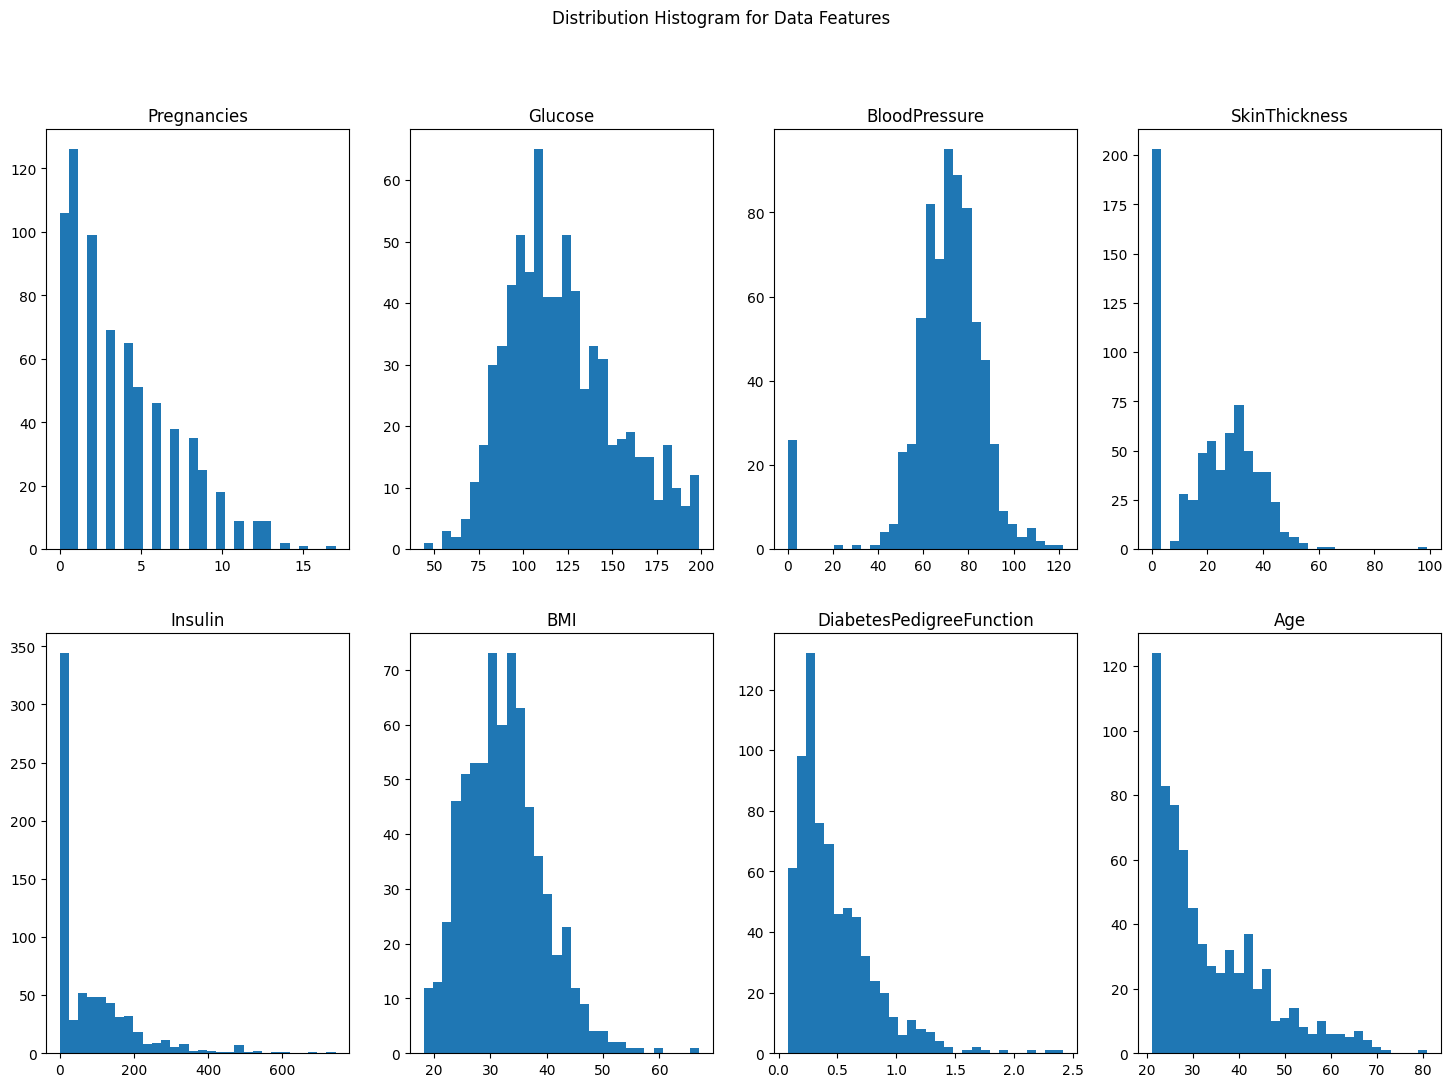

In [1720]:
fig, axs = plt.subplots(2,4,figsize = (18,12))

cols = X_pima.columns

i=0
for c in cols :
    axs[i//4,i%4].hist(X_pima[c], bins = 30)
    axs[i//4,i%4].set_title(c)
    i+=1

plt.suptitle("Distribution Histogram for Data Features")
plt.show()

## Digits

In [1721]:
digit_data = np.load("digits.npz")
digit_data

X_digits = digit_data["x"]
X_digits = X_digits.astype(np.float64)/255

Let's display some of the numbers

In [1722]:
def display_images(imgs, nil = 10) :
    nb_imgs = len(imgs)
    nb_lines = (nb_imgs-1)//nil + 1
    fig, axs = plt.subplots(nb_lines, nil, figsize=  (20,2*nb_lines))
    axs = axs.flatten()
    for i in range(len(imgs)):
        img = [imgs[i][t*28:(t+1)*28] for t in range(28)]
        ax = axs[i]
        if (len(imgs)-1)//nil > 0 : 
            ax.axis('off')
            ax.imshow(img, cmap = "gray")
            ax.set_xlim(0,28)
        else :
            axs[i%nil].axis('off')
            axs[i%nil].imshow(img, cmap = "gray")
    if len(imgs)< len(axs) :
        for i in range(len(imgs), len(axs)):
            fig.delaxes(axs[i])
    plt.tight_layout()
    plt.show()

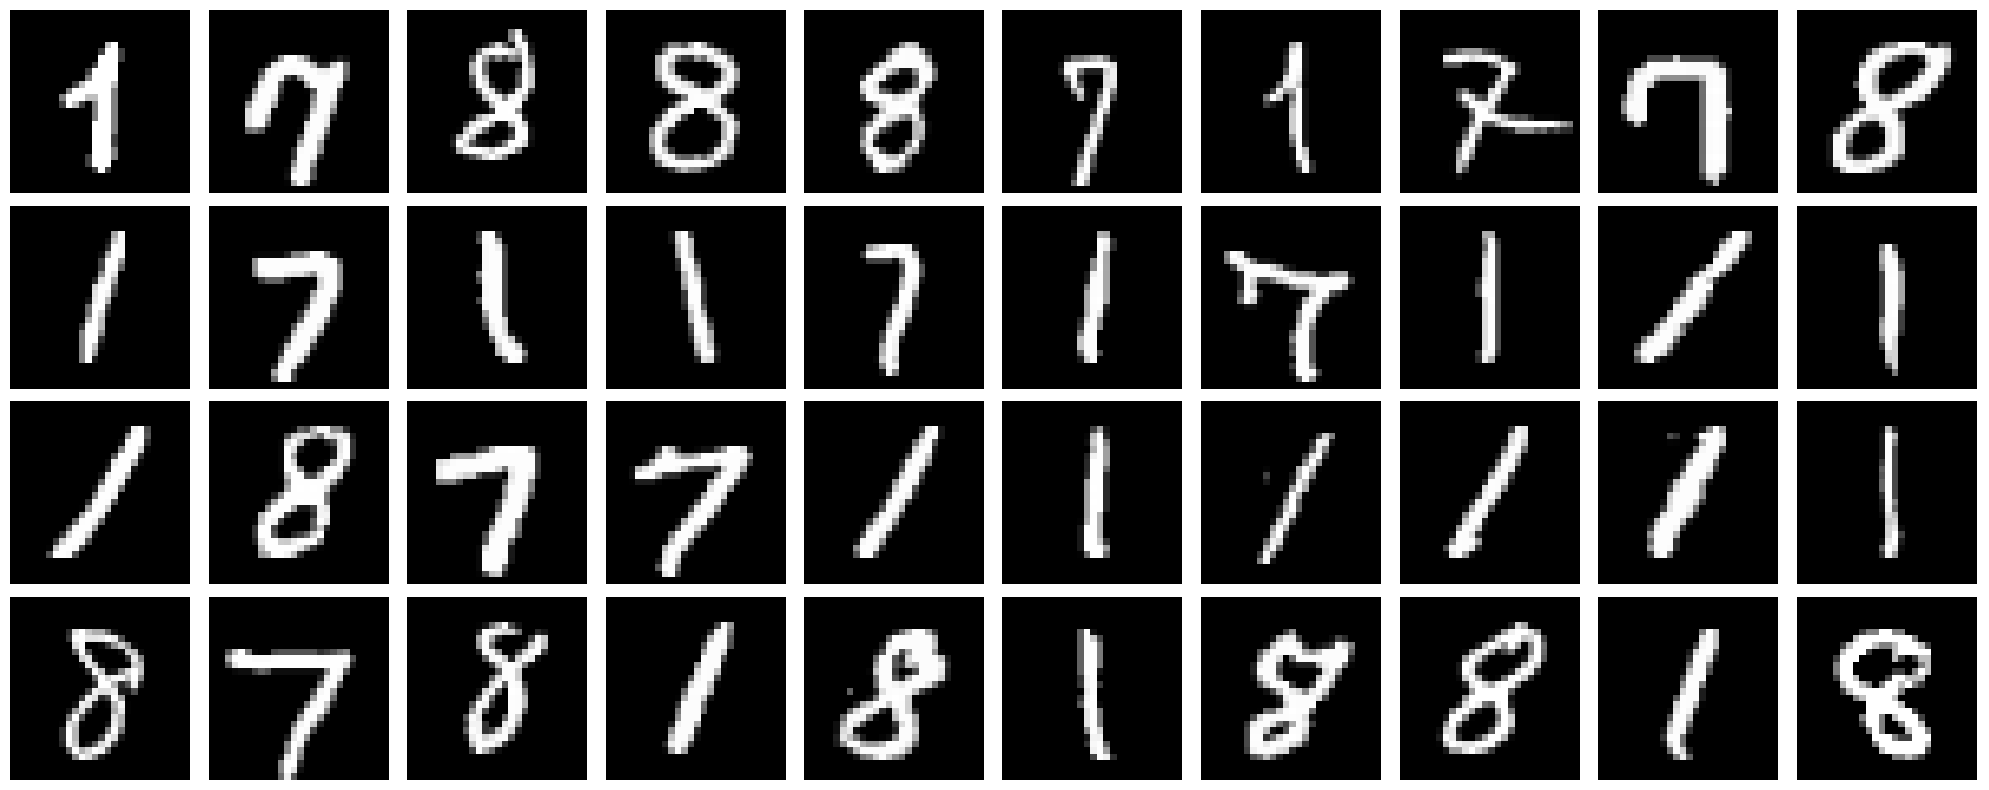

In [1723]:
rd_idx = np.random.randint(0, len(X_digits), 40)

imgs = X_digits[rd_idx]
rd_idx

display_images(imgs)


# Predicting Diabetes on Pima

## Know the Data

As all the features are type float we can display a scatterplot of all the features pair by pair

In [1724]:
XY_pima = pd.concat([X_pima, pd.DataFrame({"diabetes" : Y_pima})], axis = 1)

/var/folders/5m/n_k44ywj4w37d31x3c70zm8c0000gn/T/ipykernel_1258/1775348962.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Diabetes status", loc='upper right')


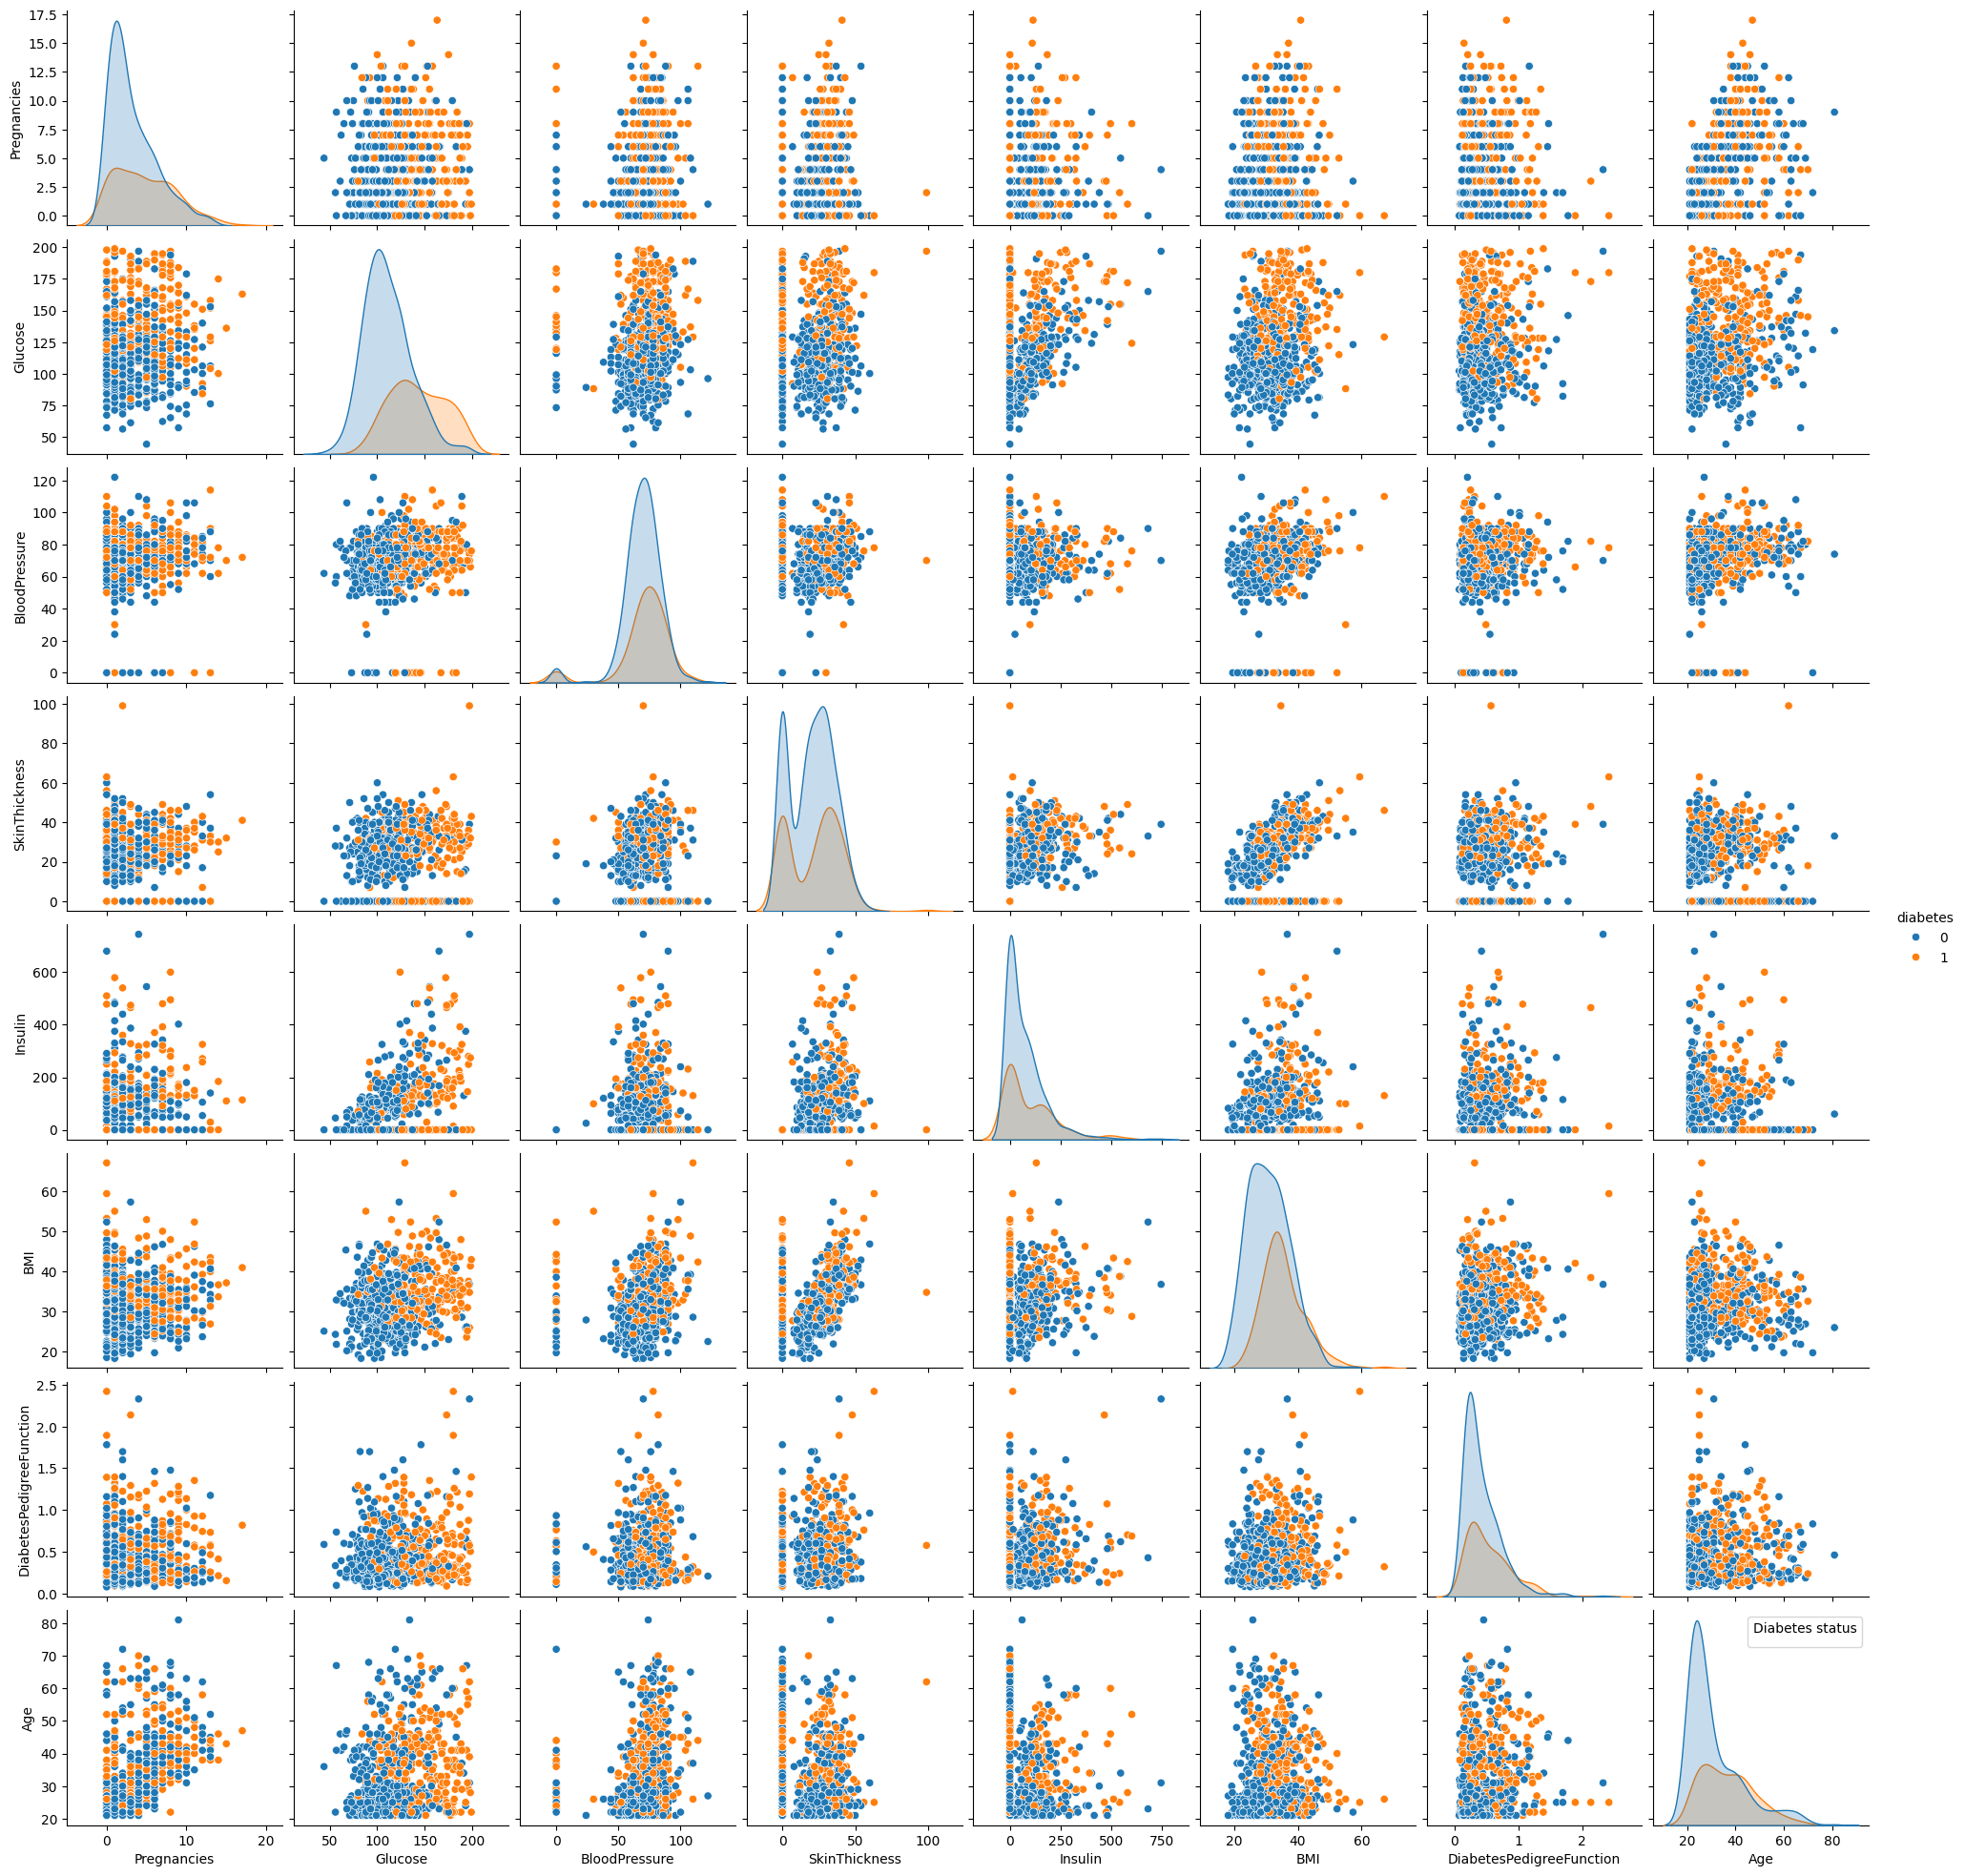

In [1725]:
g = sns.pairplot(XY_pima, hue = "diabetes", palette="tab10")

plt.legend(title="Diabetes status", loc='upper right')

plt.show()

Now let's try to identify the features that seems to help predicting the result.
 - On diagonals (different distribs)
 - On pairs (separating scatterplot) colums and lines
Surtout glucose

In [1726]:
X_pima.var()

Pregnancies                    11.152
Glucose                       929.677
BloodPressure                 328.899
SkinThickness                 252.795
Insulin                     12696.422
BMI                            48.313
DiabetesPedigreeFunction        0.106
Age                           136.168
dtype: float64

The scale can be very different from a variable to another. This could be a problem for model training (we'll see in the experiments) and for linear models interpretation (coefficients...)

In [1727]:
## Application of a scaler

from sklearn.preprocessing import StandardScaler

sscaler = StandardScaler()
X_pima_ps = sscaler.fit_transform(X_pima)

Now that our data is scaled let's check if features are intercorrelated, it could be an useful information for future works.

<Axes: >

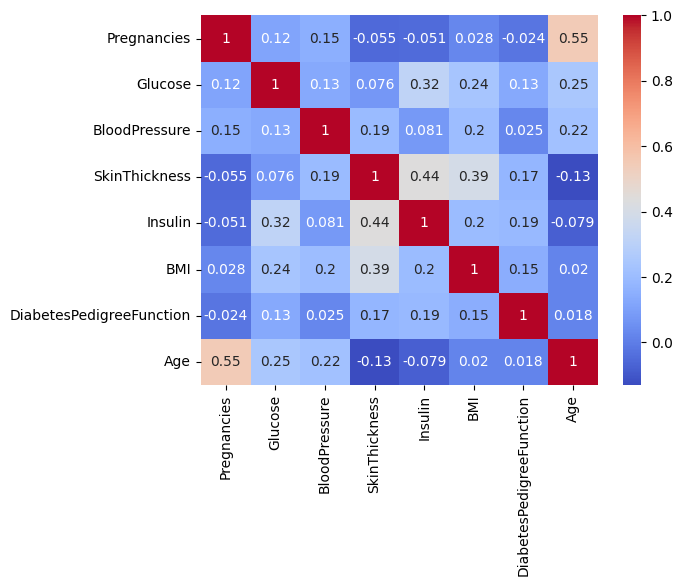

In [1728]:
sns.heatmap(pd.DataFrame(X_pima_ps, columns = pima_data['varnames']).corr(), cmap='coolwarm', annot=True)

Among all the pair of features it don't seem to have a strongly correlated one. The most intercorrelated pair is Age-Pregnancies (which is quite logical), there is also a notable intercorrelation of the pairs SkinThickness-Insulin and SkinThickness-BMI

In [1729]:
from sklearn.model_selection import train_test_split

## Splitting the data
X_train_p, X_test_p, Y_train_p, Y_test_p = train_test_split(X_pima_ps, Y_pima, train_size = 300, random_state = 42, stratify = Y_pima)

As the labels are not equiprobable we stratify our split. This asymetry in the classes is also conditioning the choice of the performance measure we'll use. As the ROC AUC is robust to an imbalance in the classes that is the performance mesure we choose to evaluate our model's performances on Pima Dataset.

This split gets us a lot of test data in comparison with the training data. This choice is relevant in our case because it allows to have a more precise and less noisy evaluation metric while keeping a sufficient number of samples for the training.

As Scikit's Grid Search function is doing the training/validation split by itself, we only split the data in two batchs : training data and test data.

In [1730]:
# X_train_p, X_val_p, Y_train_p, Y_val_p = train_test_split(X_train_p, Y_train_p, train_size = 0.8, random_state = 42, stratify=Y_train_p)

Let's split unscaled data to compare the performances with the scaled one

In [1731]:
X_train_p_noscale, X_test_p_noscale, Y_train_p_noscale, Y_test_p_noscale = train_test_split(X_pima, Y_pima, train_size = 300, random_state = 42, stratify = Y_pima)
# X_train_p_noscale, X_val_p_noscale, Y_train_p_noscale, Y_val_p_noscale = train_test_split(X_train_p_noscale, Y_train_p_noscale, train_size = 0.8, random_state = 42, stratify=Y_train_p_noscale)

## Bayesian decision and linear classification

For the purpose of diabetes detection, we aim to have both a high recall (so the diabetic patients are well identified) and a high precision (to avoid having too many false positives).

$$
\text{Recall} = \frac{TP}{TP + FN}\qquad,\qquad \text{Precision} = \frac{TP}{TP + FP}
$$

Indeed, although it could seem logical to rely solely on the recall (because in a medical application false alerts are less dangerous than missing an ill patient), it could lead to a highly arbitrary model -for example a model detecting diabetes on each patient.

The F1 Score metric offers a good compromise, allowing the simultaneous maximization of the Recall and of the Precision : 
$$
F_{1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
$$

But the issue is that the F1 Score favorizes evenly a maximization of the two metrics, and for a medical purpose we consider Recall more important than precision. To address this issue I'll use a generalized version of the F1 Score, the $F_\beta$ Score :

$$
F_{\beta} = (1 + \beta^2) \times \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}} \qquad \text{with}   \ \beta >0
$$

In this formula we can observe that the higher $\beta$ is the more Recall is important relatively to Precision. Indeed :
 
- If $\beta < 1$ Precision is more important than Recall.
- If $\beta = 1$, $F_\beta =$ F1 Score, Precision and Recall are evenly important.
- If $\beta > 1$, Recall is more important than Predicion.

It is common to select a value of $\beta$ equal to the square root of the ratio of a False Negative's cost to a False Positive's cost :

$$
\text{Cost FN} = k \times \text{Cost FP}\ , \qquad \beta = \sqrt{k}
$$

This choice of $\beta$ should result from a discussion with a medical expert. Here, I choose it arbitrary.

In [1732]:
FN_FP_COST_RATIO = 3
beta = np.sqrt(FN_FP_COST_RATIO)
print(beta_str + " =" ,beta)

β = 1.732


In [1733]:
from sklearn.metrics import fbeta_score, make_scorer

An other pertinent performance measure for our purpose is the AUC of the ROC curve. Optimal to evaluate a classification with unbalanced classes, this metric is a particulary good indicator of the separability of the predicted score space, i.e. how well the patients attributed to each class by the model are separated on this space.

##### [Function] : To compute models performances on PIMA

In [1734]:
from sklearn.base import clone

def compute_perfs_models(model, trained = False, modelns = None) : 

    if trained :
        assert modelns != None
        model1 = modelns
    else :
        model1 = clone(model)
        model.fit(X_train_p, Y_train_p)
        model1.fit(X_train_p_noscale, Y_train_p_noscale)
        

    # On scaled data

    Y_tr_p = model.predict(X_train_p)
    proba_tr_p = model.predict_proba(X_train_p)[:,1]
    Y_te_p = model.predict(X_test_p)
    proba_te_p = model.predict_proba(X_test_p)[:,1]

    # On unscaled data

    Y_tr_p1 = model1.predict(X_train_p_noscale)
    proba_tr_p1 = model1.predict_proba(X_train_p_noscale)[:,1]
    Y_te_p1 = model1.predict(X_test_p_noscale)
    proba_te_p1 = model1.predict_proba(X_test_p_noscale)[:,1]

    perfs = pd.DataFrame(index = index_perfs_temp)

    perfs["F" + beta_str + " Score"] = [
        fbeta_score(Y_train_p, Y_tr_p, beta = beta),
        fbeta_score(Y_train_p_noscale, Y_tr_p1, beta = beta),
        fbeta_score(Y_test_p, Y_te_p, beta = beta),
        fbeta_score(Y_test_p_noscale, Y_te_p1, beta = beta),
    ]

    perfs["AUC"] = [
        roc_auc_score(Y_train_p, proba_tr_p),
        roc_auc_score(Y_train_p_noscale, proba_tr_p1),
        roc_auc_score(Y_test_p, proba_te_p),
        roc_auc_score(Y_test_p_noscale, proba_te_p1)
    ]

    return model, model1, perfs

In [1735]:
best_models_p = []
index_perfs_temp = ['Training Data Scaled', 'Training Data Unscaled', 'Test Data Scaled', 'Test Data Unscaled']

### LDA

In [1736]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [1737]:
lda = LinearDiscriminantAnalysis()

lda0, lda01, perfs_lda = compute_perfs_models(lda)
print("Raw LDA Model Performances :")
perfs_lda

Raw LDA Model Performances :


,Fβ Score,AUC
Training Data Scaled,0.620,0.860
Training Data Unscaled,0.620,0.860
Test Data Scaled,0.647,0.843
Test Data Unscaled,0.647,0.843


The scaling do not improves significantly the results. It's weird that sign of output gives good auc and the same for scaling and without. There is no overfitting.


Now let's train a regularized model with shinkage.

We choose lsqr solver because it confers a more stable convergence for the model.

Training data is automatically split into training and validation data to perform hyperparameters optimization.

##### [Grid Search]

In [1738]:
from sklearn.model_selection import GridSearchCV
fbeta_scorer = make_scorer(fbeta_score, beta=beta)

In [1739]:
shrinkage_values = np.concatenate((
    [0], 
    np.logspace(-4, 0, 30)
))
params = {
    'shrinkage' : shrinkage_values
}

# On Scaled Data

lda1 = LinearDiscriminantAnalysis(solver = 'lsqr')

clf_p1 = GridSearchCV(lda1, params, cv = 5, scoring = fbeta_scorer)
clf_p1.fit(X_train_p, Y_train_p)

# On Unscaled Data

lda11 = LinearDiscriminantAnalysis(solver = 'lsqr')

clf_p2 = GridSearchCV(lda11, params, cv = 5, scoring = fbeta_scorer)
clf_p2.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,LinearDiscrim...solver='lsqr')
,param_grid,{'shrinkage': array([0.0000...00000000e+00])}
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,solver,'lsqr'


##### End [Grid Search]

In [1740]:
lda1, lda11 = clf_p1.best_estimator_, clf_p2.best_estimator_

lda1, lda11, perfs_lda1 = compute_perfs_models(lda1, trained=True, modelns = lda11)
print("Shriked LDA Performances :")
perfs_lda1

Shriked LDA Performances :


,Fβ Score,AUC
Training Data Scaled,0.624,0.854
Training Data Unscaled,0.604,0.851
Test Data Scaled,0.637,0.841
Test Data Unscaled,0.628,0.842


The optimized model's has a slightly lower $F_\beta$ Score than the LDA model without shrinkage. 

We can deduce of the slight decrease of the AUC that the LDA model separates better the data in score space without shrinkage. Let's observe this : 

##### [Function]

In [1741]:
def display_separabilities(scores, labels, titles, rowsize = 2, bins = None, figsize = [16, 6], alpha_classes = [0.6, 0.6]) :

    assert len(scores) == len(labels)
    n = len(scores)
    colsize = n//rowsize + 1 if n%rowsize>0 else n//rowsize
    fig, axs = plt.subplots(colsize, rowsize, figsize = (figsize[0], figsize[1]*colsize))

    for i in range(n) :

        if colsize>1 :
            a = axs[i//rowsize, i%rowsize]
        else :
            a = axs[i]
            
        s = scores[i]
        l = labels[i]
        idx_l_pos = [i for i, val in enumerate(l) if val == 1]
        idx_l_neg = [i for i, val in enumerate(l) if val == 0]
        s_pos, s_neg = s[idx_l_pos], s[idx_l_neg]

        n_pos, bins_pos, patches_pos = a.hist(s_pos, label = "Diabetical Patients", alpha = alpha_classes[1], bins =bins)
        n_neg, bins_neg, patches_neg =  a.hist(s_neg, label = "Healthy Patients", alpha = alpha_classes[0], bins = bins)
        for p in patches_pos + patches_neg:
            p.set_edgecolor(p.get_facecolor())
        a.legend()
        a.set_title(titles[i])
        

##### [End Function]

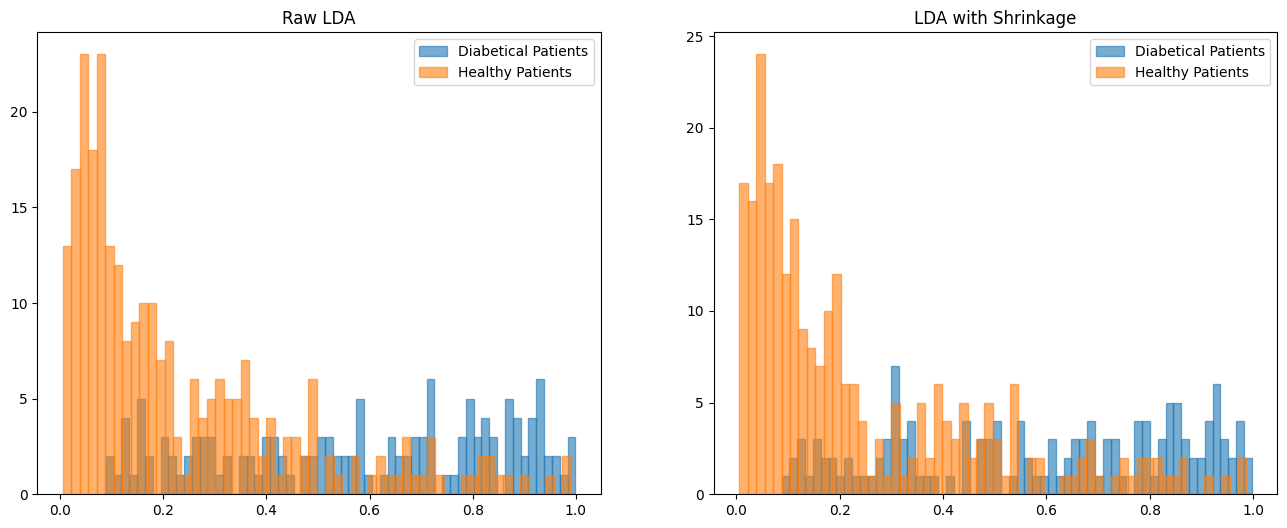

In [1742]:
t1 = "Raw LDA"
t2 = "LDA with Shrinkage"
display_separabilities([proba_test_p_lda, proba_test_p_lda_best], [Y_test_p, Y_test_p], [t1, t2], bins = 60)

Indeed we can observe that on the "low probability" part of the state space the diabetical patient's score is flatter with the raw model than with the shrinked model, which "positive" score histograms has some unwanted spikes on this part of the space. 

Why? As the data is not high dimensional $\frac{p}{n} = \frac{8}{240} = \frac{1}{300}$ the shrinkage loses his beneficial effect and add an useless bias.

Also the small size of the data (300 points) could lead to an instablility of the score during the grid search, as the data is stratified by a K-fold method.

In [1743]:
print("Shrinkage Coefficient on Scaled Data : ", lda1.shrinkage)
print("Shrinkage Coefficient on Unscaled Data : ", lda11.shrinkage)

Shrinkage Coefficient on Scaled Data :  0.728
Shrinkage Coefficient on Unscaled Data :  0.000


The optimized model trained on the unscaled data is the raw LDA model (without shrinkage). The model is not exactly the same (slightly lower AUC) but the resulting $F_\beta$ Score is the same.

As the raw LDA model has a slightly better performance (AUC and $F_\beta$ Score) than the shrinked LDA we only keep the raw model. Its performance will be stored in a DataFrame for future comparison with other models. I arbitrarily keep the model trained on unscaled data.

In [1744]:
lda_best = lda01
best_models_p.append(lda_best)

In [1745]:
perfs_p = pd.DataFrame(columns = ['Training AUC', 'Test AUC', 'Training F' + beta_str + ' Score', 'Test F' + beta_str +' Score'])
perfs_p.loc['LDA'] = [
    roc_auc_score(Y_train_p, lda_best.predict_proba(X_train_p_noscale)[:,1]),
    roc_auc_score(Y_test_p, lda_best.predict_proba(X_test_p_noscale)[:,1]),
    fbeta_score(Y_train_p, lda_best.predict(X_train_p_noscale), beta = beta),
    fbeta_score(Y_test_p, lda_best.predict(X_test_p_noscale), beta = beta)
    ]

In [1746]:
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.86,0.843,0.62,0.647


### QDA

In [1747]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

In [1748]:
qda = QuadraticDiscriminantAnalysis()

qda0, qda01, perfs_qda = compute_perfs_models(qda)
print("Raw QDA Performances :")
perfs_qda

Raw QDA Performances :


,Fβ Score,AUC
Training Data Scaled,0.610,0.869
Training Data Unscaled,0.610,0.869
Test Data Scaled,0.581,0.811
Test Data Unscaled,0.581,0.811


In [1749]:
print("Raw LDA Performances : ")
perfs_lda

Raw LDA Performances : 


,Fβ Score,AUC
Training Data Scaled,0.620,0.860
Training Data Unscaled,0.620,0.860
Test Data Scaled,0.647,0.843
Test Data Unscaled,0.647,0.843


- On training data the QDA data has a higher AUC and a lower $F_\beta$ Score than the LDA.
- On the test data both metrics are higher for the LDA is better than for the QDA.

The QDA allows to fit more precisely training data (because each class has its own covariance matrix) but it also overfits more. 
Also when the dataset is small LDA is better, also...

For Scikit's QDA, reg_param is equivalent to the shrinkage parameter for LDA. It is basically the same process except it is done (with the same coefficient) on covariance matrices of each class.

##### [Grid Search]

In [1750]:
from sklearn.model_selection import GridSearchCV

reg_values = np.concatenate((
    [0],  
    np.logspace(-4, 0, 30)  
))
params = {
    'reg_param' : reg_values
}

# On Scaled Data

qda1 = QuadraticDiscriminantAnalysis()

clf_p2 = GridSearchCV(qda1, params, cv = 5, scoring = 'roc_auc')
clf_p2.fit(X_train_p, Y_train_p)

# On Unscaled Data

qda11 = QuadraticDiscriminantAnalysis()

clf_p21 = GridSearchCV(qda11, params, cv = 5, scoring = 'roc_auc')
clf_p21.fit(X_train_p_noscale.values, Y_train_p_noscale)

,estimator,QuadraticDisc...nantAnalysis()
,param_grid,{'reg_param': array([0.0000...00000000e+00])}
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,priors,None


##### End Grid Search

In [1751]:
qda1, qda11 = clf_p2.best_estimator_, clf_p21.best_estimator_

qda1, qda11, perfs_qda1 = compute_perfs_models(qda1, trained= True, modelns=qda11)
print("Shrinked QDA Best Performances :")
perfs_qda1

Shrinked QDA Best Performances :


/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but QuadraticDiscriminantAnalysis was fitted without feature names
  warnings.warn(
/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but QuadraticDiscriminantAnalysis was fitted without feature names
  warnings.warn(
/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but QuadraticDiscriminantAnalysis was fitted without feature names
  warnings.warn(
/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but QuadraticDiscriminantAnalysis was fitted without feature names
  warnings.warn(


,Fβ Score,AUC
Training Data Scaled,0.627,0.860
Training Data Unscaled,0.610,0.865
Test Data Scaled,0.610,0.841
Test Data Unscaled,0.593,0.814


In [1752]:
print("Optimized reg_value on Training Data :", qda1.reg_param)
print("Optimized reg_value on Test Data :", qda11.reg_param)

Optimized reg_value on Training Data : 0.728
Optimized reg_value on Test Data : 0.022


Shrinkage of covariance matrices adesses the overfitting of the initial raw model and improves the separability of data points on the model's score space. We can note that shrinkage has a better effect on scaled data than on unscaled data.

Now let's conclude and compare the performance of our best QDA with those of our best LDA :

In the end our best LDA model is slightly better. It is quite explainable by the nature of our datasets, indeed LDA algorithms are more efficient on small datasets.

In [1753]:
qda_best = qda1

In [1754]:
best_models_p.append(qda_best)
perfs_p.loc['QDA'] = [
    roc_auc_score(Y_train_p, qda_best.predict_proba(X_train_p)[:,1]),
    roc_auc_score(Y_test_p, qda_best.predict_proba(X_test_p)[:,1]),
    fbeta_score(Y_train_p, qda_best.predict(X_train_p), beta = beta),
    fbeta_score(Y_test_p, qda_best.predict(X_test_p), beta = beta)
    ]

perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.86,0.843,0.620,0.647
QDA,0.86,0.841,0.627,0.610


In terms of $F_\beta$ Score the LDA is better than the QDA but in terms of AUC both models are almost equivalent. 

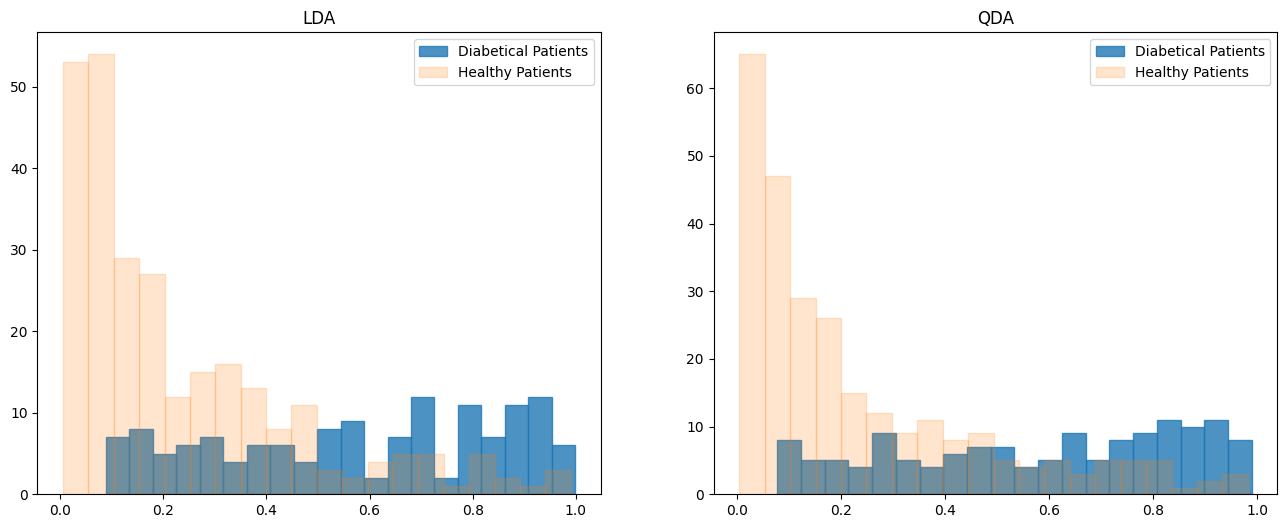

In [1931]:
t1 = "LDA"
t2 = "QDA"
display_separabilities(
    [lda_best.predict_proba(X_test_p_noscale)[:,1], qda_best.predict_proba(X_test_p)[:,1]],
    [Y_test_p, Y_test_p],
    [t1, t2],
    bins = 20,
    alpha_classes = [0.2,0.8]
)

For QDA model is still a lot of diabetical data point present in the low-probability part of the score space, which limits the separability of point in the model's score space.

The difference is that there is more diabetical points than healthy points in all the subspaces of the high-probability part of the QDA's score space. Indeed, for example, we can observe that there is very few diabetical patients in the LDA's score space between 0.6 and 0.626. There is even more healthy patients on this part of the space. In the QDA's score space all the intervals are filled with diabetical points.

We can conclude that the more precise QDA model allows to map more precisely data points on the score space, although it leads to a lower $F_\beta$ score because it tends to overfits the training data.

### Gaussian Naive Bayes

In [1756]:
from sklearn.naive_bayes import GaussianNB

In [1757]:
gnb = GaussianNB()

gnb0, gnb01, perfs_gnb = compute_perfs_models(gnb)
print("Naive Bayes Performances :")
perfs_gnb

Naive Bayes Performances :


,Fβ Score,AUC
Training Data Scaled,0.623,0.837
Training Data Unscaled,0.623,0.837
Test Data Scaled,0.674,0.834
Test Data Unscaled,0.674,0.834


Gaussian Naive Bayes has a better performance than the best LDA and QDA models we obtained. It is curious that the $F_\beta$ Score on the test data prediction is better than the performance on training data.

The performances are the same using scaled and unscaled data.

Indeed as the data don't have much highly intercorrelated features the independancy of features hypothesis can be quite appropriate. Let's check if it's still the case by separating the data accoring to its label :

In [1758]:
full_pima = pd.DataFrame(np.concatenate([X_pima_ps, np.expand_dims(np.transpose(Y_pima), 1)], axis = 1), columns = np.concatenate([pima_data["varnames"], np.array(["label"])]))

In [1759]:
pima_pos = full_pima[full_pima.label == 1]
pima_neg = full_pima[full_pima.label == 0]

In [1760]:
df_X_p_pos = pima_pos[pima_data["varnames"]]
df_X_p_neg = pima_neg[pima_data["varnames"]]

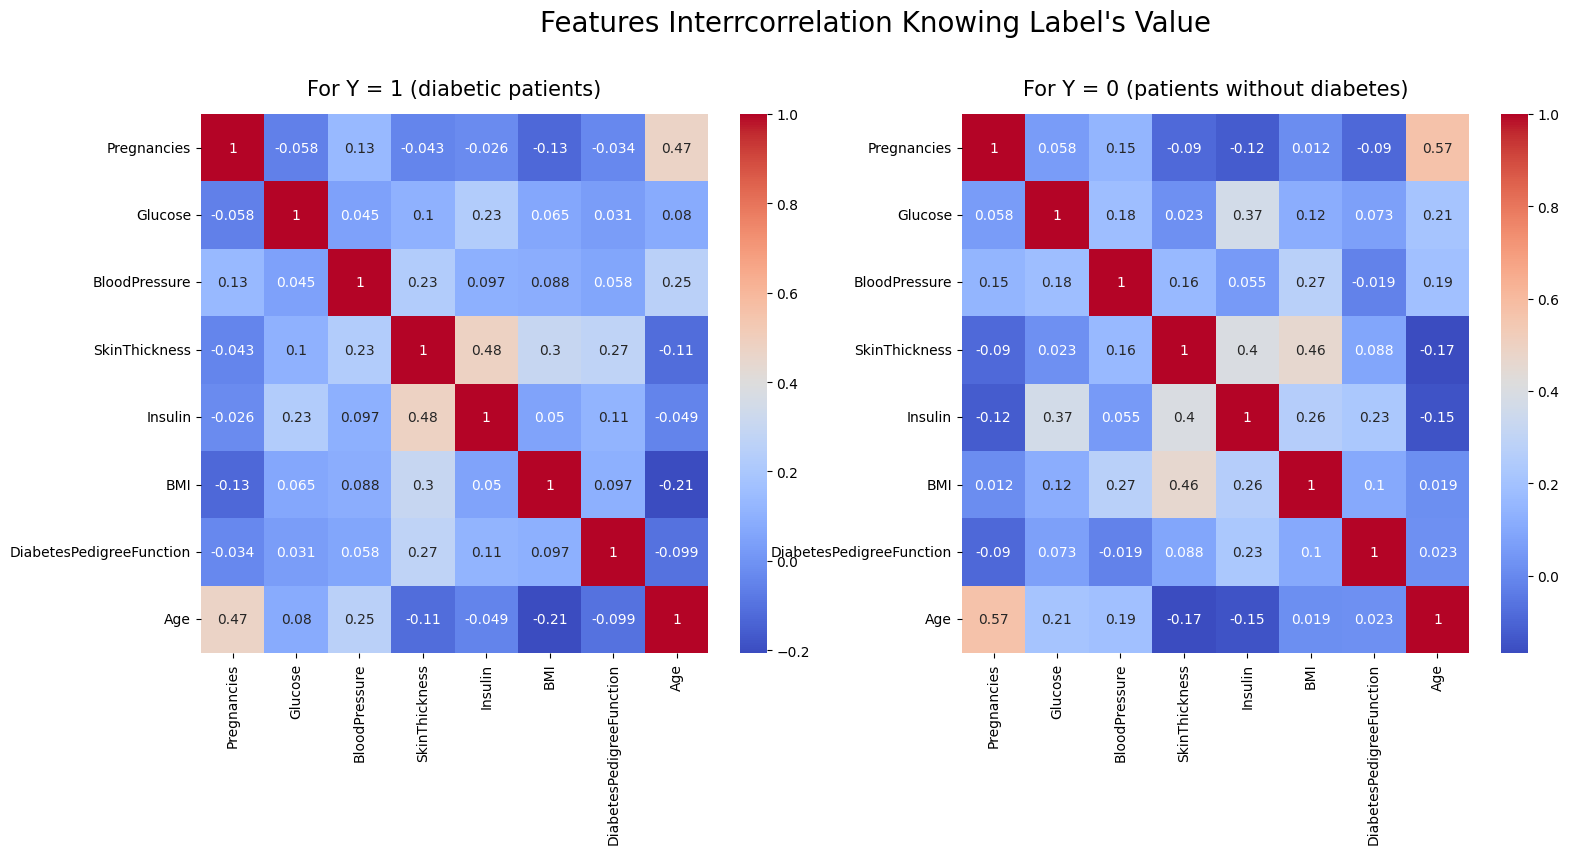

In [1761]:
fig, axs = plt.subplots(1,2, figsize = (18,7))

sns.heatmap(df_X_p_pos.corr(), cmap='coolwarm', annot=True, ax = axs[0])
axs[0].set_title("For Y = 1 (diabetic patients)", y = 1.02, fontsize = 15)

sns.heatmap(df_X_p_neg.corr(), cmap='coolwarm', annot=True, ax = axs[1])
axs[1].set_title("For Y = 0 (patients without diabetes)", y = 1.02, fontsize = 15)

plt.suptitle("Features Interrcorrelation Knowing Label's Value", y = 1.03, fontsize = 20)
plt.show()

We can observe than the two datasets contains features intercorrelation to some level, so the hypothesis is not so well respected. It is a good sign for our following work as it means the classification can be done more accurately. 

In [1762]:
gnb_best = gnb01
best_models_p.append(gnb_best)

In [1763]:
perfs_p.loc['Naive Bayes'] = [
    roc_auc_score(Y_train_p, gnb_best.predict_proba(X_train_p_noscale)[:,1]),
    roc_auc_score(Y_test_p, gnb_best.predict_proba(X_test_p_noscale)[:,1]),
    fbeta_score(Y_train_p, gnb_best.predict(X_train_p_noscale), beta = beta),
    fbeta_score(Y_test_p, gnb_best.predict(X_test_p_noscale), beta = beta)
]

perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674


In terms of Test AUC Naive Bayes model is slightly less performant than our best QDA model, which still make it significantly better than our best LDA model in terms of separability. Regarding the $F_\beta$ Score Naive Bayes is our best model by now.

Let's compare the separability of data points on QDA's and Naive Bayes's score space :

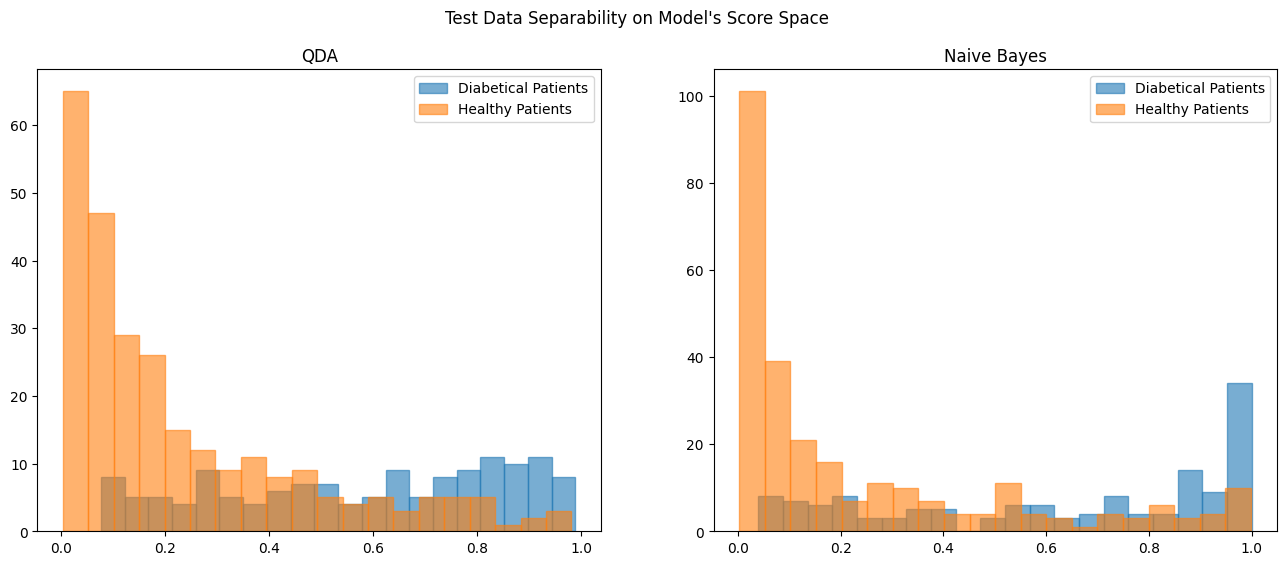

In [1764]:
t1 = "QDA"
t2 = "Naive Bayes"
display_separabilities(
    [qda_best.predict_proba(X_test_p)[:,1], proba_te_p_gnb0],
    [Y_test_p, Y_test_p],
    [t1, t2],
    bins = 20
)
plt.suptitle("Test Data Separability on Model's Score Space")
plt.show()

As there is few points with a score between 0.2 and 0.8 on Naive Baye's score space we could be tempted to see this space as more separating than QDA's. But still QDA's AUC is better than Naive Bayes's. We can explain these difference by the fact that on Naive Bayes's score space extreme values (close to 0 or to 1), there is a certain amount of the opposite label following the number of points from the correct class we except.

### Logistic Regression

In [1765]:
from sklearn.linear_model import LogisticRegression

#### Raw Model

In [1766]:
lr = LogisticRegression(random_state= 42)

lr0, lr01, perfs_lr = compute_perfs_models(lr)
print("Raw Logistic Regression Performances :")
perfs_lr

Raw Logistic Regression Performances :


/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Fβ Score,AUC
Training Data Scaled,0.613,0.862
Training Data Unscaled,0.623,0.863
Test Data Scaled,0.642,0.843
Test Data Unscaled,0.653,0.843


This time we have a better $F_\beta$ score without the scaling on the data. The AUC is still not influenced by the scaling. We can also observe that the $F_\beta$ Score are significantly better on test data than on training data (for scaled or unscaled data), although it is not the case for the AUC.

- The test $F_\beta$ Score is already better than our best LDA and QDA models's, but Naive Bayes model has a better $F_\beta$ score than this raw model.
- The test AUC is already the best we ever had (slightly better than the test AUC of QDA model).

#### Basic Logistic Regression with Class Weight

As we have small dataset, the liblinear solver is used because it peforms better (DETAIL). Also we give the information of the class weight for the model to take into consideration the imbalance dimension of the labels, so the weight of the error is weighted (the rarest class has a relatively larger weight) so errors on each class have the same impact on the loss function.

In [1767]:
lr = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', random_state= 42)

lr02, lr03, perfs_lr = compute_perfs_models(lr)
print("Balanced Logistic Regression Performances :")
perfs_lr

Balanced Logistic Regression Performances :


,Fβ Score,AUC
Training Data Scaled,0.713,0.864
Training Data Unscaled,0.744,0.849
Test Data Scaled,0.709,0.842
Test Data Unscaled,0.739,0.844


Adapting the weight of each class on the loss function improves significantly the $F_\beta$ Score of the model, even if the AUC don't change much. With this update we get our best model (by far) from now on.

#### L1 Regularization

Let's add a regularization to see if we can improve our results on the test data.

##### [Grid Search]

In [1768]:
# L1 Regularization on scaled data

logreg1 = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', penalty= 'l1', random_state = 42)

l1_value = np.logspace(-3, 1, 30)
params = {
    'C' : l1_value
}

clf_p3 = GridSearchCV(logreg1, params, cv = 5, scoring = fbeta_scorer)
clf_p3.fit(X_train_p, Y_train_p)

# L1 Regularization on unscaled data

logreg11 = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', penalty= 'l1', random_state = 42)

clf_p4 = GridSearchCV(logreg11, params, cv = 5, scoring = fbeta_scorer)
clf_p4.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,LogisticRegre...r='liblinear')
,param_grid,{'C': array([1.0000...00000000e+01])}
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


##### End [Grid Search]

In [1769]:
lr1, lr11 = clf_p3.best_estimator_, clf_p4.best_estimator_

lr1, lr11, perfs_lr1 = compute_perfs_models(lr1, trained = True, modelns=lr11)
print("L1 Regularized Logistic Regression Performances :")
perfs_lr1

L1 Regularized Logistic Regression Performances :


,Fβ Score,AUC
Training Data Scaled,0.713,0.864
Training Data Unscaled,0.705,0.857
Test Data Scaled,0.707,0.841
Test Data Unscaled,0.736,0.847


In [1770]:
print("Lambda on Scaled Data : ", lr1.C)
print("Lambda on Unscaled Data : ", lr11.C)

Lambda on Scaled Data :  5.298
Lambda on Unscaled Data :  0.418


Now to improve lisibility on results displaying let's only keep the AUC and the $F_\beta$ score and separate to have a DataFrame for each metric.

In [1771]:
perfs_lr_reg_f = pd.DataFrame(index = ['Test Data Scaled', 'Test Data Unscaled'])

perfs_lr_reg_f['Balanced'] = [fbeta_score(Y_test_p, lr02.predict(X_test_p), beta = beta), fbeta_score(Y_test_p, lr03.predict(X_test_p_noscale), beta = beta)]
perfs_lr_reg_f['L1'] = [fbeta_score(Y_test_p, lr1.predict(X_test_p), beta = beta), fbeta_score(Y_test_p, lr11.predict(X_test_p_noscale), beta = beta)]

print("Models Fbeta Score :")
perfs_lr_reg_f

Models Fbeta Score :


,Balanced,L1
Test Data Scaled,0.709,0.707
Test Data Unscaled,0.739,0.736


In [1772]:
perfs_lr_reg_auc = pd.DataFrame(index = ['Test Data Scaled', 'Test Data Unscaled'])

perfs_lr_reg_auc['Balanced'] = [roc_auc_score(Y_test_p, lr02.predict_proba(X_test_p)[:,1]), roc_auc_score(Y_test_p, lr03.predict_proba(X_test_p_noscale)[:,1])]
perfs_lr_reg_auc['L1'] = [roc_auc_score(Y_test_p, lr1.predict_proba(X_test_p)[:,1]), roc_auc_score(Y_test_p, lr11.predict_proba(X_test_p_noscale)[:,1])]

print("Models AUC :")
perfs_lr_reg_auc

Models AUC :


,Balanced,L1
Test Data Scaled,0.842,0.841
Test Data Unscaled,0.844,0.847


#### L2 Regularization

##### [Grid Search]

In [1773]:
# L2 Regularization on Scaled Data

logreg2 = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', penalty= 'l2', random_state=42)

l2_value = np.logspace(-3, 1, 30)
params = {
    'C' : l2_value
}

clf_p5 = GridSearchCV(logreg2, params, cv = 5, scoring = fbeta_scorer)
clf_p5.fit(X_train_p, Y_train_p)

# L2 Regularization on Unscaled Data

logreg21 = LogisticRegression(solver = 'liblinear', class_weight = 'balanced', penalty= 'l2', random_state=42)

clf_p6 = GridSearchCV(logreg21, params, cv = 5, scoring = fbeta_scorer)
clf_p6.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,LogisticRegre...r='liblinear')
,param_grid,{'C': array([1.0000...00000000e+01])}
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


##### End [Grid Search]

In [1774]:
lr2, lr21 = clf_p5.best_estimator_, clf_p6.best_estimator_

lr2, lr21, perfs_lr2 = compute_perfs_models(lr2, trained = True, modelns = lr21)
print("L2 Regularized Model Performances :")
perfs_lr2

L2 Regularized Model Performances :


,Fβ Score,AUC
Training Data Scaled,0.738,0.858
Training Data Unscaled,0.753,0.850
Test Data Scaled,0.712,0.842
Test Data Unscaled,0.739,0.844


In [1775]:
print("Lambda on Scaled Data : ", lr2.C)
print("Lambda on Unscaled Data : ", lr21.C)

Lambda on Scaled Data :  0.013
Lambda on Unscaled Data :  1.083


In [1776]:
perfs_lr_reg_f["L2"] = [
    fbeta_score(Y_test_p, lr2.predict(X_test_p), beta = beta),
    fbeta_score(Y_test_p_noscale, lr21.predict(X_test_p_noscale), beta = beta)
]

perfs_lr_reg_auc["L2"] = [
    roc_auc_score(Y_test_p, lr2.predict_proba(X_test_p)[:,1]),
    roc_auc_score(Y_test_p_noscale, lr21.predict_proba(X_test_p_noscale)[:,1])
]

#### Elastic Net Regularization

##### [Grid Search]

In [ ]:
# Elastic Net on Scaled Data

logreg3 = LogisticRegression(solver = 'saga', class_weight = 'balanced', penalty= 'elasticnet', random_state=42)

l1_ratio_values = (
    np.linspace(0, 1, 30)  
)
params = {
    'C' : l2_value,
    'l1_ratio' : l1_ratio_values
}

clf_p7 = GridSearchCV(logreg3, params, cv = 5, scoring = fbeta_scorer)
clf_p7.fit(X_train_p, Y_train_p)

# Elastic Net on Unscaled Data

logreg31 = LogisticRegression(solver = 'saga', class_weight = 'balanced', penalty= 'elasticnet', random_state=42)

clf_p8 = GridSearchCV(logreg31, params, cv = 5, scoring = fbeta_scorer)
clf_p8.fit(X_train_p_noscale, Y_train_p_noscale)

##### End [Grid Search]

In [1778]:
lr3, lr31 = clf_p7.best_estimator_, clf_p8.best_estimator_

lr3, lr31, perfs_lr3 = compute_perfs_models(lr3, trained=True, modelns=lr31)
print("Elastic Net Model Performances : ")
perfs_lr3

Elastic Net Model Performances : 


,Fβ Score,AUC
Training Data Scaled,0.708,0.862
Training Data Unscaled,0.669,0.729
Test Data Scaled,0.708,0.843
Test Data Unscaled,0.693,0.734


In [1779]:
print("On Scaled Data : \n - lambda : ", lr3.C, "\n - ratio : ", lr3.l1_ratio)
print("On Unscaled Data : \n - lambda : ", lr31.C, "\n - ratio : ", lr31.l1_ratio)

On Scaled Data : 
 - lambda :  0.045 
 - ratio :  0.000
On Unscaled Data : 
 - lambda :  0.001 
 - ratio :  0.586


Note that the optimal L1 Ratio is 0 for scaled data, meaning that the best model has solely a L2 regularization.

##### [Digression] Impact of the Solver on Grid Search's Result

We could have excepted that we have the same $\lambda$ coefficient than the one we obtained in the L2 regularized model's Grid Search ($\lambda = 0.013$). As the splitting of the data made by Scikit's Grid Search (KFold by default) is purely deterministic, this difference can only be explained by the difference of solver. Let's verify this by doing the same Grid Search we've done for L2 regularization but replacing the liblinear solver by the saga :

In [1780]:
# L2 Regularization on Scaled Data with Saga Solver

logreg22 = LogisticRegression(solver = 'saga', class_weight = 'balanced', penalty= 'l2', random_state=42)

params = {'C' : l2_value}

clf_p9 = GridSearchCV(logreg22, params, cv = 5, scoring = fbeta_scorer)
clf_p9.fit(X_train_p, Y_train_p)

,estimator,LogisticRegre...solver='saga')
,param_grid,{'C': array([1.0000...00000000e+01])}
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [1781]:
# Get Best Model (Scaled Data)

logreg22 = clf_p9.best_estimator_
print("Lambda on Scaled Data : ", logreg22.C)

Lambda on Scaled Data :  0.045


##### End of[Digression]

Indeed we obtain the same value that for the Elastic Net model ($\lambda = 0.045$), meaning that the solver has a significant impact of the optimal coefficient selected.

In [1782]:
perfs_lr_reg_f["Elastic Net"] = [
    fbeta_score(Y_test_p, lr3.predict(X_test_p), beta = beta),
    fbeta_score(Y_test_p_noscale, lr31.predict(X_test_p_noscale), beta = beta)
]

perfs_lr_reg_auc["Elastic Net"] = [
    roc_auc_score(Y_test_p, lr3.predict_proba(X_test_p)[:,1]),
    roc_auc_score(Y_test_p_noscale, lr31.predict_proba(X_test_p_noscale)[:,1])
]

In [1783]:
print("F"+ beta_str + " Score for Different Logistic Regressions : ")
perfs_lr_reg_f

Fβ Score for Different Logistic Regressions : 


,Balanced,L1,L2,Elastic Net
Test Data Scaled,0.709,0.707,0.712,0.708
Test Data Unscaled,0.739,0.736,0.739,0.693


In [1784]:
print("AUC for Different Logistic Regressions : ")
perfs_lr_reg_auc

AUC for Different Logistic Regressions : 


,Balanced,L1,L2,Elastic Net
Test Data Scaled,0.842,0.841,0.842,0.843
Test Data Unscaled,0.844,0.847,0.844,0.734


On unscaled data, the Elastic Net scores are significantly lower than those of the other logistic regression models. It shouldn't be the case as Grid Search on Elastic Net is supposed to explore the models we got for Grid Search on L1 and L2 regularization. We can guess this error is due to the instablility due to the K-Fold cross validation included Scikit Learn's Grid Search algorithm and the fact that validation data (selected among training data) could be too restricted.

COMMENT

- The best models according to $F_\beta$ Score are (equal value) the balanced model and the L2 regularized model trained on unscaled data.
- According to the AUC almost all models (except Elastic Net) models are equivalent, even if the L1 regularized model is separating slightly better test data. Also (except for the Elastic Net), the AUC is slightly better for models trained on unscaled data than for models trained on scaled data.

#### Coefficients Comparison

As models trained on unscaled data are the best, we'll start to display their coefficients and compare them. Next we'll do the same with logistic regressions trained on scaled data.

In [1785]:
colors = plt.cm.tab10.colors
print(colors)

((0.12156862745098039, 0.4666666666666667, 0.7058823529411765), (1.0, 0.4980392156862745, 0.054901960784313725), (0.17254901960784313, 0.6274509803921569, 0.17254901960784313), (0.8392156862745098, 0.15294117647058825, 0.1568627450980392), (0.5803921568627451, 0.403921568627451, 0.7411764705882353), (0.5490196078431373, 0.33725490196078434, 0.29411764705882354), (0.8901960784313725, 0.4666666666666667, 0.7607843137254902), (0.4980392156862745, 0.4980392156862745, 0.4980392156862745), (0.7372549019607844, 0.7411764705882353, 0.13333333333333333), (0.09019607843137255, 0.7450980392156863, 0.8117647058823529))


##### Regressions Trained on Scaled Data

In [1786]:
logreg0_b = lr03
logreg1_b = lr11
logreg2_b = lr21
logreg3_b = lr31

###### [Function] To display Coefficients

In [1787]:
def display_coefs(list_coefs, list_coef_names, offset = 0.1) : 

    plt.figure()

    assert len(list_coefs)>0 

    n = len(list_coefs)
    decalage = np.linspace(-(n-1)*0.5, (n-1)*0.5, n)
    n_features = len(list_coefs[0])
    x = np.arange(n_features)
    print(decalage)

    for i in range(n) :
        markerline1, stemlines1, baseline1 = plt.stem(x + decalage[i]*offset, list_coefs[i], linefmt='C0-', markerfmt=' ', basefmt='k-', label = list_coef_names[i])
        plt.xticks(x, pima_data["varnames"], rotation = 90)
        plt.setp(stemlines1, color = TAB10_NAMES[i], linewidth=3.5)
        plt.setp(markerline1, 'color', TAB10_NAMES[i])
        plt.setp(baseline1, color='black', linewidth=0.2)

    plt.legend()

###### End [Function]

###### [Function] 

To scale coefficients via standard deviation :

As models we'll vizualise are trained on unscaled data we need to scale the coefficients so we have a pertinent representation of each feature's importance. To this end we multiply each feature's coefficient by the standard deviation of the feature concerned (a change of mean on the data don't have any consequence on the coefficient others than the intercept).

In [1788]:
def transform_coef(coefs, data) : 
    n = len(coefs)
    n_coefs = []
    cols = data.columns
    assert n == len(cols)
    for i in range(n) :
        n_coefs.append(coefs[i]*data[cols[i]].std())
    return n_coefs

###### End [Function]

In [1789]:
coef0_viz = transform_coef(logreg0_b.coef_[0], X_pima)
coef1_viz = transform_coef(logreg1_b.coef_[0], X_pima)
coef2_viz = transform_coef(logreg2_b.coef_[0], X_pima)
coef3_viz = transform_coef(logreg3_b.coef_[0], X_pima)

[-1.5 -0.5  0.5  1.5]


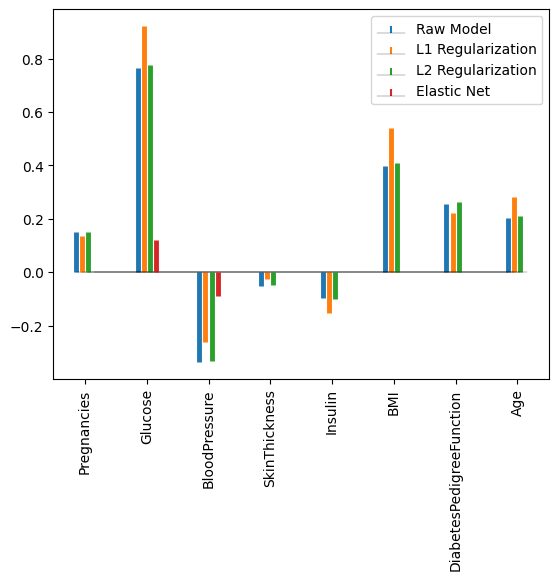

In [1790]:
list_coefs = [coef0_viz, coef1_viz, coef2_viz, coef3_viz]
list_coef_names = ['Raw Model', 'L1 Regularization', 'L2 Regularization', 'Elastic Net']

display_coefs(list_coefs, list_coef_names)
plt.show()

Here the L1 regularization don't eliminate coefficients but it accentuates the importance of highly representative features (glucose, BMI, age...) relatively to the others. 


##### Logistic Regressions on Scaled Data

In [1791]:
coef0_viz = lr02.coef_[0]
coef1_viz = lr1.coef_[0]
coef2_viz = lr2.coef_[0]
coef3_viz = lr3.coef_[0]

[-1.5 -0.5  0.5  1.5]


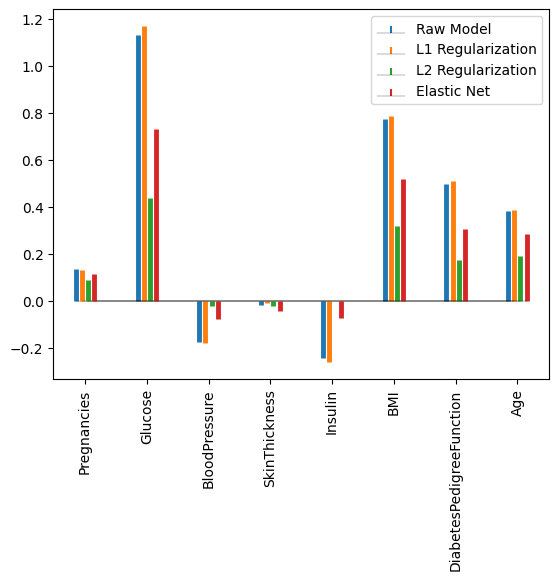

In [1792]:
list_coefs = [coef0_viz, coef1_viz, coef2_viz, coef3_viz]
list_coef_names = ['Raw Model', 'L1 Regularization', 'L2 Regularization', 'Elastic Net']

display_coefs(list_coefs, list_coef_names)
plt.show()

For model trained on Standad Scaled data the importance of glucose, BMI and age is accentuated compared to the other features importance. Except for the insulin which negative impact increases, the other feature's (pregnancies, blood pressure, skin thickness...) relative importance diminishes.

Also we observe that the L2 regularization homogenenizes strongly the absolute value of coefficients.
It is curious that L1 Regularization don't generate sparse coefficients as the $\lambda$ coefficient is quite high : $\lambda = 5.30$. Indeed the effect of the L2 regularization seems much more important although the model's $\lambda$ is quite low : $\lambda = 0.013$.


In [1793]:
print("L1 lambda : ",lr1.C)
print("L2 lambda : ",lr2.C)

L1 lambda :  5.298
L2 lambda :  0.013


#### Final Choice

The relative absolute value of regression coefficient seems coherent in a mediacal point of view, as the pima dataset's aim is to detect Type 2 Diabetes, which occurs more for aged patient with a high Body Mass Index (especially if obese) and with familial antecedents. 

As the L2 Optimally Regularized model and the Balanced Model on unscaled data are almost equivalent we keep the balanced model (on unscaled data) as our best Logistic Regression.

In [1934]:
lr_best = lr03

In [1833]:
best_models_p.append(best_lr)
perfs_p.loc['Logistic Regression'] = [
    roc_auc_score(Y_train_p_noscale, lr_best.predict_proba(X_train_p_noscale)[:,1]),
    roc_auc_score(Y_test_p_noscale, lr_best.predict_proba(X_test_p_noscale)[:,1]),
    fbeta_score(Y_train_p_noscale, lr_best.predict(X_train_p_noscale), beta = beta),
    fbeta_score(Y_test_p_noscale, lr_best.predict(X_test_p_noscale), beta = beta)
]

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682
SVC,0.872,0.825,0.753,0.735
MLP,0.934,0.830,0.776,0.629
XGBoost,0.980,0.812,0.899,0.734
Logistic Regression,0.849,0.844,0.744,0.739


### Data Separability in Scores Space

In [1946]:
models = [lda_best, qda_best, gnb_best, lr_best]
scaledornot = [False, True, False, False]
X_datas = [X_test_p if s else X_test_p_noscale for s in scaledornot]
Y_datas = [Y_test_p if s else Y_test_p_noscale for s in scaledornot]

probas_models = [models[i].predict_proba(X_datas[i])[:,1] for i in range(4)]

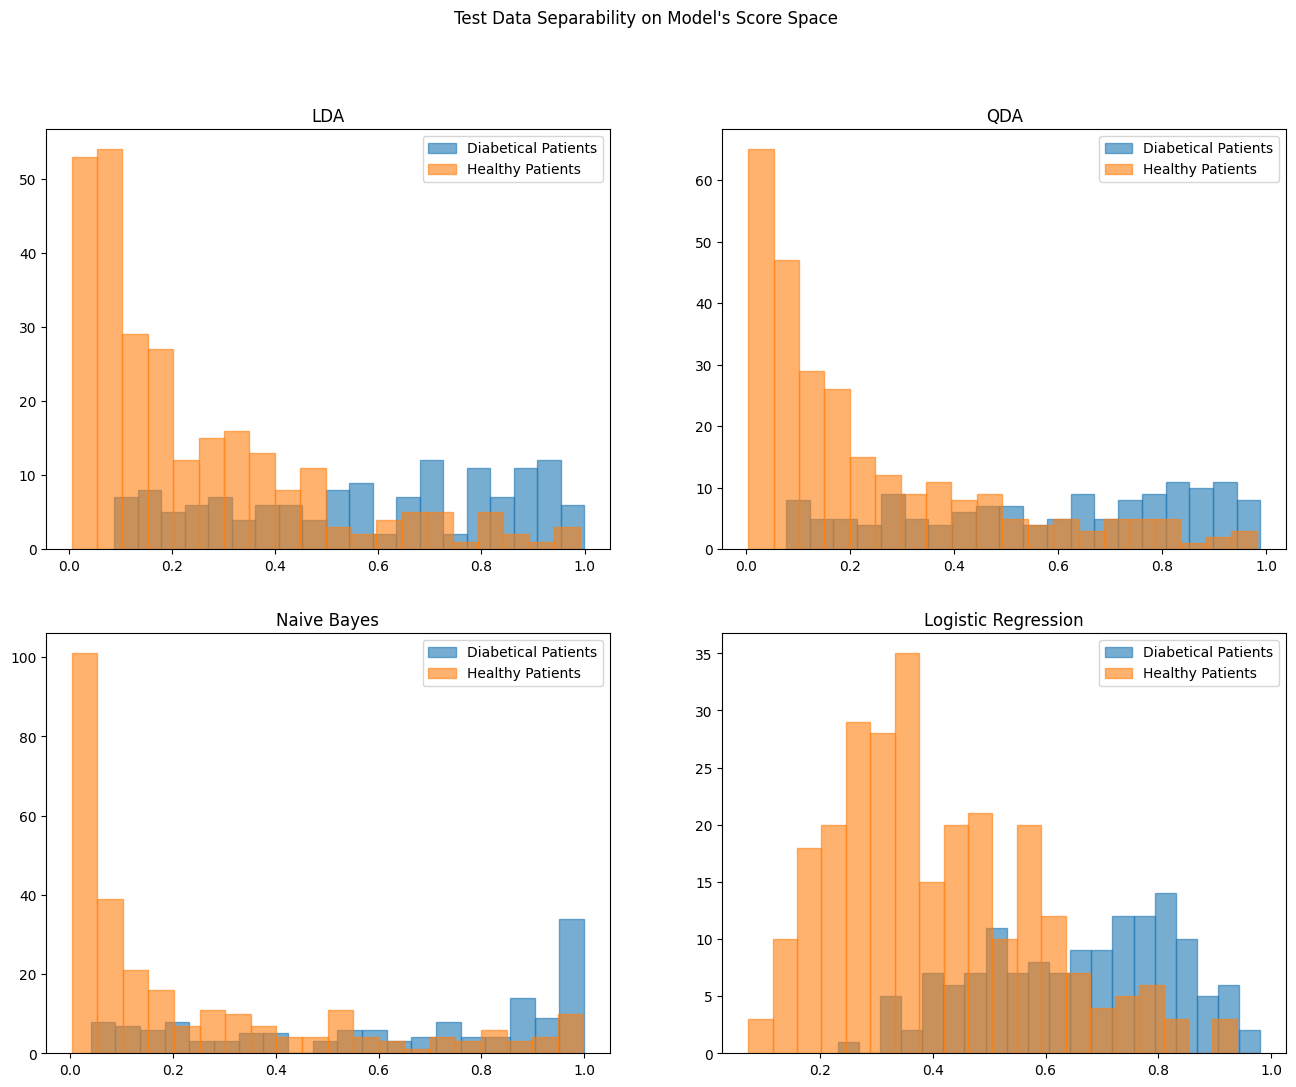

In [1947]:
titles = ['LDA', 'QDA', 'Naive Bayes', 'Logistic Regression']
display_separabilities(
    probas_models,
    Y_datas,
    titles,
    bins = 20
)
plt.suptitle("Test Data Separability on Model's Score Space")
plt.show()

In [1954]:
perfs_p.loc[['LDA', 'QDA', 'Naive Bayes', 'Logistic Regression']][['Test AUC']].sort_values(by = 'Test AUC', ascending = False)

,Test AUC
Logistic Regression,0.844
LDA,0.843
QDA,0.841
Naive Bayes,0.834


As the three first model's probabilities displays approximately the same form (probabilities values are more extreme with Naive Bayes), the Logistic Regression shows a different scheme, however leading to a slightly better AUC.
 - One of the advantages of these distributions is that zero sane patients have a probability superior to 0.95 and zero ill patients have a probability lower than 0.2. 
 - On the other side there is a lot of patient with an intermediate probability (between 0.2 and 0.8), as the initial threshold of the logistic regression is fixed to 0.5 it surely leads to imprecisions. That's why it is important to adjust the threshold, and that is what we're going to do in further studies so we can have a model aligned with our medical task.

## Non Linear Methods

As we observe some intercorrelation between some features, non linear models should have better results on this dataset. 

### Random Forest Classifier

In [1794]:
from sklearn.ensemble import RandomForestClassifier

In [1795]:
rf = RandomForestClassifier(random_state= 42, class_weight= 'balanced')

rf0, rf01, perfs_rf = compute_perfs_models(rf)
perfs_rf

,Fβ Score,AUC
Training Data Scaled,1.000,1.000
Training Data Unscaled,1.000,1.000
Test Data Scaled,0.560,0.818
Test Data Unscaled,0.553,0.819


The resulting models perfectly fit the training data but overfits a lot (the performances on test data are lower than our more simple linear and quadratic models). Model's performance is the same on scaled and unscaled data.

Let's try to improve performances on test data by doing a grid search on random forest's parameters.

In [ ]:
# On scaled data

rf1 = RandomForestClassifier(random_state= 42, max_samples = 1.0, class_weight='balanced')

params = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [1, 2, 5],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [0.25, 0.5, 0.75],
}

clf_p10 = GridSearchCV(rf1, params, cv = 5, scoring = fbeta_scorer)
clf_p10.fit(X_train_p, Y_train_p)

In [1797]:
# On unscaled data

rf11 = RandomForestClassifier(random_state= 42, max_samples = 1.0, class_weight = 'balanced')

params = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [0.5, 1, 2],
}

clf_p11 = GridSearchCV(rf11, params, cv = 5, scoring = fbeta_scorer)
clf_p11.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...], 'max_features': [0.5, 1, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [1798]:
rf1, rf11 = clf_p10.best_estimator_, clf_p11.best_estimator_

rf1, rf11, perfs_p_rf1 = compute_perfs_models(rf1, trained = True, modelns = rf11)
print("Optimized Random Forest Performances : ")
perfs_p_rf1

Optimized Random Forest Performances : 


,Fβ Score,AUC
Training Data Scaled,0.885,0.975
Training Data Unscaled,0.896,0.964
Test Data Scaled,0.646,0.823
Test Data Unscaled,0.682,0.819


In [1799]:
print("Raw Random Forest Performances : ")
perfs_p_rf

Raw Random Forest Performances : 


,Fβ Score,AUC
Training Data Scaled,1.000,1.000
Training Data Unscaled,1.000,1.000
Test Data Scaled,0.568,0.817
Test Data Unscaled,0.575,0.818


The Hyperparameters Optimization allows to imporve the performances of the Random Forest Classifier. The best model we obtain is the optimized classifier trained on unscaled data but it still overfits a lot.

In [1800]:
best_rf = rf11
best_models_p.append(best_rf)

In [1801]:
perfs_p.loc['Random Forest'] = [
    roc_auc_score(Y_train_p_noscale, best_rf.predict_proba(X_train_p_noscale)[:,1]),
    roc_auc_score(Y_test_p_noscale, best_rf.predict_proba(X_test_p_noscale)[:,1]),
    fbeta_score(Y_train_p_noscale, best_rf.predict(X_train_p_noscale), beta = beta),
    fbeta_score(Y_test_p_noscale, best_rf.predict(X_test_p_noscale), beta = beta)
]
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682


### SVC

As the classes are unbalanced we put the parameter 'class_weight' equal to 'balanced'.

In [1802]:
from sklearn.svm import SVC

In [1803]:
svc = SVC(random_state = 42, probability = True, class_weight='balanced')

svc0, svc01, perfs_svc = compute_perfs_models(svc)
print("RBF SVC Performances : ")
perfs_svc

RBF SVC Performances : 


,Fβ Score,AUC
Training Data Scaled,0.834,0.938
Training Data Unscaled,0.709,0.847
Test Data Scaled,0.688,0.821
Test Data Unscaled,0.694,0.817


In [1804]:
svc = SVC(random_state = 42, probability = True, kernel = 'linear', class_weight='balanced')

svc02, svc03, perfs_svc1 = compute_perfs_models(svc)
print("Linear SVC Performances : ")
perfs_svc1

Linear SVC Performances : 


,Fβ Score,AUC
Training Data Scaled,0.715,0.863
Training Data Unscaled,0.699,0.863
Test Data Scaled,0.695,0.843
Test Data Unscaled,0.694,0.846


In [1805]:
svc = SVC(random_state = 42, probability = True, kernel = 'poly', class_weight='balanced')

svc04, svc05, perfs_svc2 = compute_perfs_models(svc)
print("Polynomnial SVC Performances : ")
perfs_svc2

Polynomnial SVC Performances : 


,Fβ Score,AUC
Training Data Scaled,0.725,0.924
Training Data Unscaled,0.673,0.859
Test Data Scaled,0.556,0.808
Test Data Unscaled,0.632,0.815


With the default kernel RBF and a balanced class weight we obtain a quite satisfying first model, both in terms of $F_\beta$ Score and AUC (despite it overfits a bit). We observe that the model performs better on unscaled data than on scaled data. Without this parameter, models trained on scaled and unscaled data are very far from satisfying in terms of $F_\beta$ score (the models AUC is still fine).

With a linear kernel we have the same results but the training duration is way longer. With a polynomial kernel the performances metrics are lower.

Let's try to optimize the hyperparameters C and $\gamma$ to see if we can have better results :

In [1806]:
# On scaled data

svc1 = SVC(random_state = 42, probability = True, class_weight='balanced')

params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}
clf_p12 = GridSearchCV(svc1, params, cv = 5, scoring = fbeta_scorer)
clf_p12.fit(X_train_p, Y_train_p)

# On unscaled data

svc11 = SVC(random_state = 42, probability = True, class_weight='balanced')

clf_p13 = GridSearchCV(svc11, params, cv = 5, scoring = fbeta_scorer)
clf_p13.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,SVC(class_wei...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'gamma': ['scale', 'auto', ...]}"
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [1807]:
svc1, svc11 = clf_p12.best_estimator_, clf_p13.best_estimator_

svc1, svc11, perfs_svc3 = compute_perfs_models(svc1, trained = True, modelns=svc11)
print("Optimized RBF SVC Performances : ")
perfs_svc3

Optimized RBF SVC Performances : 


,Fβ Score,AUC
Training Data Scaled,0.753,0.872
Training Data Unscaled,0.826,0.944
Test Data Scaled,0.735,0.825
Test Data Unscaled,0.672,0.771


In [1808]:
svc1.C, svc1.gamma

(0.1, 'scale')

With hyperparameters optimization we obtain better results. Finally our best SVC model is trained on scaled data with $C = 0.1$ and $\gamma =$ 'scale'.

In [1809]:
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682


In [1810]:
best_models_p.append(svc1)
perfs_p.loc['SVC'] = [
    roc_auc_score(Y_train_p, svc1.predict_proba(X_train_p)[:,1]),
    roc_auc_score(Y_test_p, svc1.predict_proba(X_test_p)[:,1]),
    fbeta_score(Y_train_p, svc1.predict(X_train_p), beta = beta),
    fbeta_score(Y_test_p, svc1.predict(X_test_p), beta = beta)
]
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682
SVC,0.872,0.825,0.753,0.735


### MLP Classifer

As early stopping don't reduce the overfitting and reduces the results we don't use it here.

In [1811]:
from sklearn.neural_network import MLPClassifier

In [1812]:
mlp = MLPClassifier(random_state = 42)

mlp0, mlp01, perfs_mlp = compute_perfs_models(mlp)
print("Raw MLP Performances : ")
perfs_mlp

Raw MLP Performances : 


/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,Fβ Score,AUC
Training Data Scaled,0.776,0.934
Training Data Unscaled,0.739,0.879
Test Data Scaled,0.629,0.830
Test Data Unscaled,0.528,0.715


This raw MLP model is not very satisfying, it overfits a lot and don't even have very good performances on the training data, leaving few hopes for the results of the optimized model that I try to do anyways :

##### [Grid Search]

In [1813]:
params = {
    'hidden_layer_sizes': [
        (32,), (64,), (64, 32), (128, 64)
    ],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [0.001, 0.01],
    'activation': ['relu', 'tanh'],
    'early_stopping': [True], 
    'max_iter': [1000]
}

# On scaled data

mlp1 = MLPClassifier(random_state = 42)

clf_p14 = GridSearchCV(mlp1, params, cv = 5, scoring = fbeta_scorer)
clf_p14.fit(X_train_p, Y_train_p)

# On unscaled data

mlp11 = MLPClassifier(random_state = 42)

clf_p15 = GridSearchCV(mlp11, params, cv = 5, scoring = fbeta_scorer)
clf_p15.fit(X_train_p_noscale, Y_train_p_noscale)

,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [1e-05, 0.0001, ...], 'early_stopping': [True], 'hidden_layer_sizes': [(32,), (64,), ...], ...}"
,scoring,make_scorer(f...0508075688772)
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(64, ...)"


##### End [Grid Search]

In [1814]:
mlp1, mlp11 = clf_p14.best_estimator_, clf_p15.best_estimator_

mlp1, mlp11, perfs_mlp1 = compute_perfs_models(mlp1, trained = True, modelns = mlp11)
perfs_mlp1

,Fβ Score,AUC
Training Data Scaled,0.663,0.853
Training Data Unscaled,0.521,0.707
Test Data Scaled,0.633,0.839
Test Data Unscaled,0.559,0.685


In [1815]:
perfs_mlp

,Fβ Score,AUC
Training Data Scaled,0.776,0.934
Training Data Unscaled,0.739,0.879
Test Data Scaled,0.629,0.830
Test Data Unscaled,0.528,0.715


The Grid Search don't improve the results. Our best model is the raw model trained on scaled data.

In [1816]:
best_mlp = mlp0
best_models_p.append(best_mlp)

In [1817]:
perfs_p.loc['MLP'] = [
    roc_auc_score(Y_train_p, best_mlp.predict_proba(X_train_p)[:,1]),
    roc_auc_score(Y_test_p, best_mlp.predict_proba(X_test_p)[:,1]),
    fbeta_score(Y_train_p, best_mlp.predict(X_train_p), beta = beta),
    fbeta_score(Y_test_p, best_mlp.predict(X_test_p), beta = beta)
]
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682
SVC,0.872,0.825,0.753,0.735
MLP,0.934,0.830,0.776,0.629


### XGBoost

In [1818]:
from xgboost import XGBClassifier

In [1819]:
Y_tr_valcounts = pd.Series(Y_train_p).value_counts()
scale_pos_weight = Y_tr_valcounts[0]/Y_tr_valcounts[1]
print(scale_pos_weight)

1.941


In [1820]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight, 
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [1821]:
xgb0, xgb01, perfs_xgb = compute_perfs_models(xgb)
print("Raw XGBoost Performances : ")
perfs_xgb

Raw XGBoost Performances : 


/Users/gabriel/venv1/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:51:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/gabriel/venv1/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:51:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Fβ Score,AUC
Training Data Scaled,1.000,1.000
Training Data Unscaled,1.000,1.000
Test Data Scaled,0.562,0.781
Test Data Unscaled,0.562,0.781


The raw model overfits a lot. Let's optimize hyperparameters to see if we can improve predictions on test data. As a Grid Search would be very long, let's try a Randomized Search.

##### [Random Search]

In [ ]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

xgb1 = XGBClassifier(
    scale_pos_weight=scale_pos_weight, 
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb11 = XGBClassifier(
    scale_pos_weight=scale_pos_weight, 
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(2, 5),
    'learning_rate': uniform(0.01, 0.09),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 1),
    'reg_lambda': uniform(1, 10),
    'reg_alpha': uniform(0, 1),
    'scale_pos_weight': [1, 2, 3]
}

# On Scaled Data

rs1 = RandomizedSearchCV(
    xgb1,
    param_distributions=param_dist,
    n_iter=40,
    scoring=fbeta_scorer,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
rs1.fit(X_train_p, Y_train_p)

# On Unscaled Data

rs2 = RandomizedSearchCV(
    xgb11,
    param_distributions=param_dist,
    n_iter=40,
    scoring=fbeta_scorer,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)
rs2.fit(X_train_p_noscale, Y_train_p_noscale)

##### End [Random Search]

In [1823]:
xgb1, xgb11 = rs1.best_estimator_, rs2.best_estimator_

xgb1, xgb11, perfs_xgb1 = compute_perfs_models(xgb1, trained = True, modelns = xgb11)
print("Raw XGBoost Performances : ")
perfs_xgb1

Raw XGBoost Performances : 


,Fβ Score,AUC
Training Data Scaled,0.899,0.980
Training Data Unscaled,0.899,0.980
Test Data Scaled,0.734,0.812
Test Data Unscaled,0.734,0.812


Hyperparameter Optimization adesses overfitting problems and improves predictions on test data (better AUC and way better $F_\beta$ Score). Note that XGBoost provides exactly the same results on scaled and unscaled data. We'll keep the model trained on unscaled data.

In [1824]:
best_xgb = xgb11
best_models_p.append(best_xgb)

In [1825]:
perfs_p.loc['XGBoost'] = [
    roc_auc_score(Y_train_p, best_xgb.predict_proba(X_train_p_noscale)[:,1]),
    roc_auc_score(Y_test_p, best_xgb.predict_proba(X_test_p_noscale)[:,1]),
    fbeta_score(Y_train_p, best_xgb.predict(X_train_p_noscale), beta = beta),
    fbeta_score(Y_test_p, best_xgb.predict(X_test_p_noscale), beta = beta)
]
perfs_p

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
LDA,0.860,0.843,0.620,0.647
QDA,0.860,0.841,0.627,0.610
Naive Bayes,0.837,0.834,0.623,0.674
Random Forest,0.964,0.819,0.896,0.682
SVC,0.872,0.825,0.753,0.735
MLP,0.934,0.830,0.776,0.629
XGBoost,0.980,0.812,0.899,0.734


## Comparison and Interpretation

Let's first review our results by now :

In [1836]:
perfs_p.sort_values(by = "Test F"+beta_str+" Score", ascending = False)

,Training AUC,Test AUC,Training Fβ Score,Test Fβ Score
Logistic Regression,0.849,0.844,0.744,0.739
SVC,0.872,0.825,0.753,0.735
XGBoost,0.980,0.812,0.899,0.734
Random Forest,0.964,0.819,0.896,0.682
Naive Bayes,0.837,0.834,0.623,0.674
LDA,0.860,0.843,0.620,0.647
MLP,0.934,0.830,0.776,0.629
QDA,0.860,0.841,0.627,0.610


According to both the $F_\beta$ Score and the AUC, our best model is the Logistic Regression. This result seem to confirm that identifying non linear relation is unnecessay in this application. According to the choice we made to use the $F_\beta$ Score as reference metric we have a model aligned for a medical application (the choice of $\beta  = \sqrt3$ was made quite arbitrarily but it could be adjusted easily in the code).

Let's display the confusion matrix of our best model :

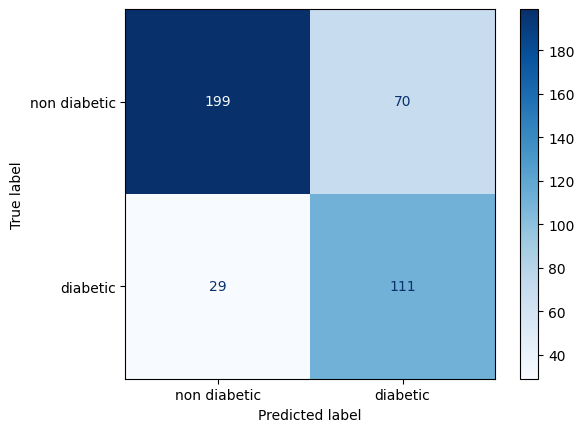

In [1841]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model_p = lr03
Y_te_p_best = lr03.predict(X_test_p_noscale)
cm = confusion_matrix(Y_test_p, Y_te_p_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['non diabetic', 'diabetic'])
disp.plot(cmap='Blues', colorbar=True)

In [1845]:
fnr = cm[1,0]/(cm[1,0]+ cm[1,1])
print(fnr)

0.207


With this model the false negative rate is : $FNR = \frac{FN}{FN + TP} = 0.207$. For an immediate diagnostic it would be way too high, but as this data aims at predicting if a person will have diabetes in the next five years this imprecision can be tolerable, even if this result as a whole is not ideal.


### Approach 1 : change the decision threshold

To diminish our FNR under a threshold of 10% (that would lead to a safer model to use for medical application), let's modify the threshold used by our model. To that end it is useful to display the ROC curve of our best model. As FNR = 1 - TPR (True Positive Rate) we want : $TPR \geq 0.9$.

In [1862]:
np.where(tpr > 0.9)[0][0]

np.int64(146)

/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


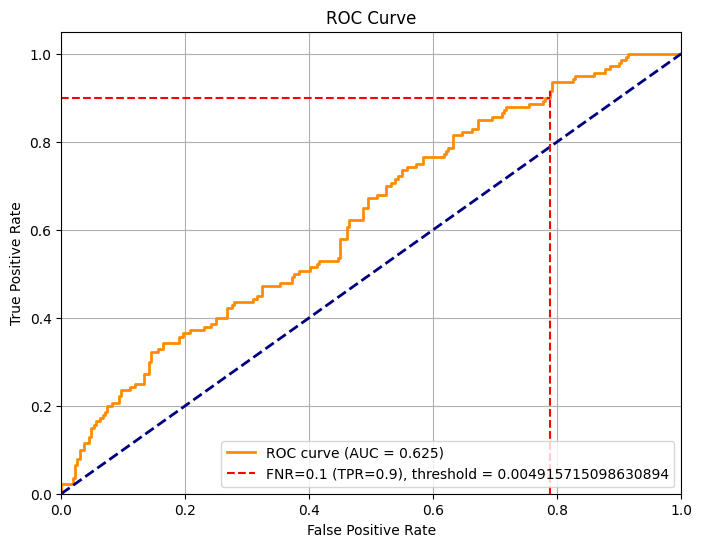

In [1868]:
from sklearn.metrics import roc_curve, auc

proba_te_p_best = best_model_p.predict_proba(X_test_p)[:,1]

fpr, tpr, thresholds = roc_curve(Y_test_p, proba_te_p_best)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
intersection_idx = np.where(tpr > 0.9)[0][0]
plt.hlines(y=0.9, xmin = 0, xmax = fpr[intersection_idx], color='red', linestyle='--', label=f'FNR=0.1 (TPR=0.9)')
plt.vlines(x= fpr[intersection_idx], ymin = 0, ymax = tpr[intersection_idx], color='red', linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [1871]:
threshold = thresholds[intersection_idx]
print(threshold*1000)

4.916


So to have a model that has a FNR lower than $10\%$ we need to fix the threshold at $t =4.910*10^{-3}$, meaning that if the predicted probability is superior to $t$ the model classifies the patient as a future diabetic.

### Approach 2 : change the intercept of the model

An other solution to artificially change the decision threshold of the model is to make vary the intercept of our model. To this end I'll display the FNR of a list of variants of the model by changing progressively the intercept.

In [1879]:
from copy import deepcopy
print(best_model_p.intercept_[0])

-4.651


In [1898]:
list_intercepts = np.linspace(-7, -3, 10000)
fnrs = []

for i in list_intercepts :
    m = deepcopy(best_model_p)
    m.intercept_ = i
    tn, fp, fn, tp = confusion_matrix(Y_test_p_noscale, m.predict(X_test_p_noscale)).ravel()
    fnrs.append(fn / (fn + tp))

best_intercept_idx = np.where(np.array(fnrs) < 0.1)[0][0]
best_intercept = list_intercepts[best_intercept_idx]
print("The optimal intercept value is ", best_intercept, ", with a resulting FNR of", fnrs[best_intercept_idx])

The optimal intercept value is  -4.297 , with a resulting FNR of 0.093


In [1899]:
best_model_pter = deepcopy(best_model_p)
best_model_pter.intercept_ = best_intercept

### Upgraded Models and Performances

Let's compute $F_\beta$ Scores of our upgraded models. Logically the AUC don't change with the changes we've done because it is the area under the ROC curve, which is not modified.

In [1905]:
perfs_up_models = pd.DataFrame(index = ['Approach 1', 'Approach 2', 'Old Model'])

proba_te_p_bestbis = best_model_p.predict_proba(X_test_p_noscale)[:,1]
Y_te_p_bestbis = [1 if p > threshold else 0 for p in proba_te_p_bestbis]

perfs_up_models['Fbeta Score'] = [
    fbeta_score(Y_test_p_noscale, Y_te_p_bestbis, beta = beta),
    fbeta_score(Y_test_p_noscale, best_model_pter.predict(X_test_p_noscale), beta = beta),
    fbeta_score(Y_test_p_noscale, best_model_p.predict(X_test_p_noscale), beta = beta)
]

perfs_up_models

,Fbeta Score
Approach 1,0.676
Approach 2,0.771
Old Model,0.739


- The approach 1 diminishes the $F_\beta$ Score. It is probably because the threshold is very small, this could lead to computation imprecisions notably during the estimation of the treshold.
- The approach 2 significantly improves the Fbeta Score, proving the efficiency of the $F_\beta$ Score in favorizing a low FNR. However it also reveal the incapacity of basic training and opimization procedures to maximize this score.

Finally let's display our model's confusion matrices :

Text(0.5, 1.0, '2nd Approach')

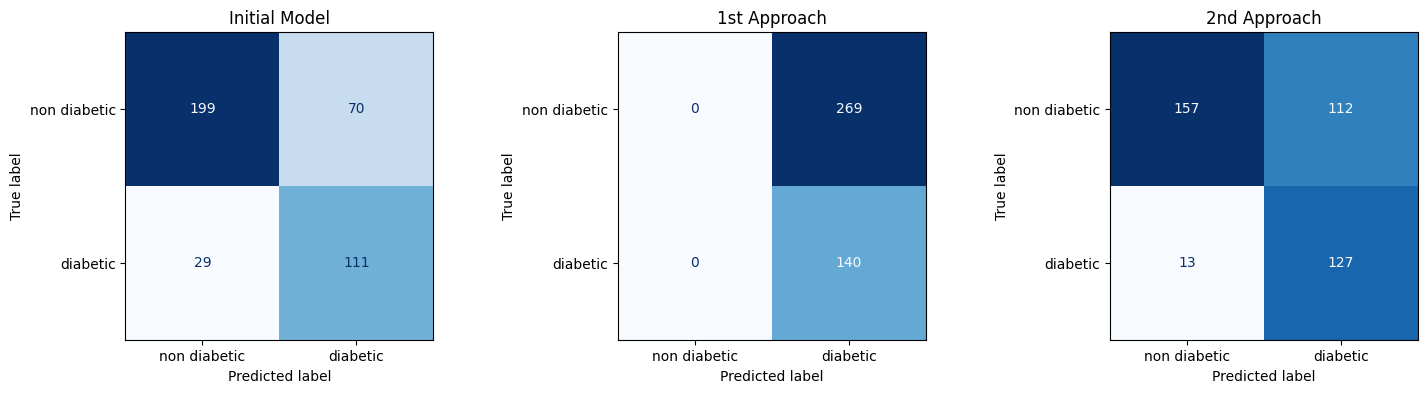

In [1917]:
fig, axs = plt.subplots(1,3, figsize = (18, 4))

# Initial Best Model
cm0 = confusion_matrix(Y_test_p, Y_te_p_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm0, display_labels=['non diabetic', 'diabetic'])
disp.plot(ax = axs[0], cmap='Blues', colorbar = False)
axs[0].set_title("Initial Model")

# 1st Approach
cm1 = confusion_matrix(Y_test_p, Y_te_p_bestbis)
disp = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['non diabetic', 'diabetic'])
disp.plot(ax = axs[1], cmap='Blues', colorbar = False)
axs[1].set_title("1st Approach")

# 2nd Approach
cm2 = confusion_matrix(Y_test_p, best_model_pter.predict(X_test_p_noscale))
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['non diabetic', 'diabetic'])
disp.plot(ax = axs[2], cmap='Blues', colorbar = False)
axs[2].set_title("2nd Approach")

In [1921]:
fdr = cm2[0,1]/(cm2[0,1]+ cm2[1,1])
print("2nd Approach FDR =", fdr)

2nd Approach FDR = 0.469


- We can observe that the 1st Approach is too extreme and always predict diabetes (which is coherent with the decrease in $F_\beta$ score and proves the pertinence of using this score as it is also penalizing too extrem of a model).

- The 2nd approach is providing us a model respecting the maximum value of the FNR while capable of identifying patients that are not likely to be diabetic. We can however point out this flaw : it has (logically) a very high False Discovery Rate : $FDR = \frac{FP}{FP+TP} = 0.47$

# Predicting Classes on Digits Dataset

For this part we'll used unscaled data as scaling data could lead to a loss of information (for example the standard deviation is useful to identify pixels that are almost always very close to 0)

In [1922]:
X_train_d = digit_data["xt"].astype(np.float64)/255
Y_train_d = digit_data["yt"][:,0]
X_test_d = digit_data["x"].astype(np.float64)/255
Y_test_d = digit_data["y"][:,0]

Let's look at the proportion of classes to prevent an evntual inbalance within the classes :

In [1923]:
print("Proportion of classes in the training data : \n", pd.Series(Y_train_d).value_counts())
print("Proportion of classes in the test data : \n", pd.Series(Y_test_d).value_counts())

Proportion of classes in the training data : 
 1    500
7    500
8    500
Name: count, dtype: int64
Proportion of classes in the test data : 
 1    1000
7    1000
8    1000
Name: count, dtype: int64


## Evaluation of Supervised Methods

As the classes are all equivalently represented in our datasets (train and test), we can use the accuracy as our main performance score. 

In [961]:
from sklearn.metrics import accuracy_score

### LDA

In [1924]:
ldad0 = LinearDiscriminantAnalysis()
ldad0.fit(X_train_d, Y_train_d)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,False
,tol,0.0001
,covariance_estimator,None


In [1925]:
Y_tr_d_lda0 = ldad0.predict(X_train_d)
Y_te_d_lda0 = ldad0.predict(X_test_d)

print("Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_lda0))
print("Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_lda0))

Training Accuracy :  0.996
Test Accuracy :  0.897


LDA is almost perfectly efficient on training data but overfits, let's try to add a shrinkage and optimize it using Grid Search :

In [1926]:
ldad1 = LinearDiscriminantAnalysis(solver = 'lsqr')

params = {
    'shrinkage' : shrinkage_values
}

clf_d1 = GridSearchCV(ldad1, params, cv = 5, scoring = 'accuracy')
clf_d1.fit(X_train_d, Y_train_d)

,estimator,LinearDiscrim...solver='lsqr')
,param_grid,{'shrinkage': array([0.0000...00000000e+00])}
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,solver,'lsqr'


In [965]:
ldad1 = clf_d1.best_estimator_

Y_tr_d_lda1 = ldad1.predict(X_train_d)
Y_te_d_lda1 = ldad1.predict(X_test_d)

print("Raw Model")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_lda0))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_lda0))

print("\nOptimized Model (coefficient =", ldad1.shrinkage ,")")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_lda1))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_lda1))

Raw Model
 - Training Accuracy :  0.996
 - Test Accuracy :  0.897

Optimized Model (coefficient = 0.530 )
 - Training Accuracy :  0.975
 - Test Accuracy :  0.959


Adding shrinkage improves the results by reducing the model's overfitting. Let's store the model's accuracy so we'll be able to compare it with further models :

In [1003]:
perfs_d = pd.Series([])
best_models_d = []

In [1004]:
ldad_best = ldad1
best_models_d.append(ldad_best)
perfs_d.loc['LDA'] =  accuracy_score(Y_test_d, Y_te_d_lda1)
perfs_d

LDA    0.959
dtype: float64

### Logistic Regression

As our dataset is not so large (since we only have 3 numbers) it is more pertinent to use the Multinomial Logistic Regression (whose only flaw is to be slower) instead of the One vs Rest Logistic Regression. It is conveninent because this is the approach selected by default on Scikit's Logistic Regressions on multiclass data.  We choose the lbfgs solver to ensure model's robustness.

In [967]:
logregd0 = LogisticRegression(solver = 'lbfgs', random_state = 42)
logregd0.fit(X_train_d, Y_train_d)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [968]:
Y_tr_d_reglog0= logregd0.predict(X_train_d)
Y_te_d_reglog0 = logregd0.predict(X_test_d)

print("Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_reglog0))
print("Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_reglog0))

Training Accuracy :  1.000
Test Accuracy :  0.972


This model predicts almost perfectly training labels and almost perfectly the test labels. Let's see if we can still improve these results with a regularization.

In [969]:
test = LogisticRegression(solver = 'saga', penalty = 'l1', l1_ratio = 0.5, random_state = 42)
test.fit(X_train_d, Y_train_d)

/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/gabriel/venv1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


##### [Grid Search] L1, L2 and Elastic Net Regularization

In [ ]:
# Grid Search for L1 Regularization

logregd11 = LogisticRegression(solver = 'saga', penalty= 'l1', random_state = 42)

params = {
    'C' : l2_value
}

clf_d2 = GridSearchCV(logregd11, params, cv = 5, scoring = 'accuracy')
clf_d2.fit(X_train_d, Y_train_d)

# Grid Search for L2 Regularization

logregd1 = LogisticRegression(solver = 'lbfgs', penalty = 'l2', random_state = 42)

params = {
    'C' : l2_value
}

clf_d3 = GridSearchCV(logregd1, params, cv = 5, scoring = 'accuracy')
clf_d3.fit(X_train_d, Y_train_d)



In [ ]:
C_opt = logregd1.C

# Grid Search for Elastic Net Regularization

l1_ratio_values = np.linspace(0,1, 30)

logregd12 = LogisticRegression(solver = 'saga', penalty = 'elasticnet', C = C_opt, random_state = 42)

params = {
    'l1_ratio' : l1_ratio_values
}

clf_d4 = GridSearchCV(logregd12, params, cv = 5, scoring = 'accuracy')
clf_d4.fit(X_train_d, Y_train_d)

##### End [Grid Search]

In [972]:
logregd1 = clf_d2.best_estimator_
logregd11 = clf_d3.best_estimator_

Y_tr_d_reglog1 = logregd1.predict(X_train_d)
Y_te_d_reglog1 = logregd1.predict(X_test_d)

Y_tr_d_reglog11 = logregd11.predict(X_train_d)
Y_te_d_reglog11 = logregd11.predict(X_test_d)

In [1928]:
print("L1 Regularized Model Lambda =", logregd1.C)
print("L2 Regularized Model Lambda =", logregd11.C)

L1 Regularized Model Lambda = 7.279
L2 Regularized Model Lambda = 7.279


As $\lambda = 7.279$ for both regularization types, we can fix this value for the Grid Search with Elastic Net Regularization, so that the only parameter variying is going to be l1_ratio (so the optimization is not too long).

In [973]:
logregd12 = clf_d4.best_estimator_


Y_tr_d_reglog12 = logregd12.predict(X_train_d)
Y_te_d_reglog12 = logregd12.predict(X_test_d)


print("L1 Model Test Accuracy (lambda = ",logregd1.C,") : ", accuracy_score(Y_test_d, Y_te_d_reglog1))
print("L2 Model Test Accuracy (lambda = ",logregd11.C,") : ", accuracy_score(Y_test_d, Y_te_d_reglog11))
print("Elastic Net Model Test Accuracy (lambda = ",logregd12.C,", l1_ratio = ",logregd12.l1_ratio,") :", accuracy_score(Y_test_d, Y_te_d_reglog12))

L1 Model Test Accuracy (lambda =  7.279 ) :  0.974
L2 Model Test Accuracy (lambda =  7.279 ) :  0.973
Elastic Net Model Test Accuracy (lambda =  1.000 , l1_ratio =  0.000 ) : 0.974


We can observe that Elastic Net Regularization gives a purely L2 regularized model. This result can seem strange but as the difference of accuracy between the L1 and L2 Regularized model is quasi-negligible, we can guess that the L1 model can have a better accuracy than the L2 model on validation data selected by the KFold of the Grid Search. As these validation sets are way smaller than our test set we rely on the accuracy we have on this data and conclude that the L1 regularized model is the best. But in fact the difference in accuracy is so small that we could take a model independently of its regularization.

##### [Function]


In [974]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def vizualise_coefs(coefs, names, rowlen = 4, img_size = 28) :

    n = len(coefs)
    assert n == len(names)
    if n%4 == 0 :
        collen = n//4
    else : 
        collen = n//4 + 1 
    vmin = min([np.abs(c).min() for c in coefs])
    vmax = max([np.abs(c).max() for c in coefs])

    fig, axs = plt.subplots(collen, rowlen, figsize = (16,6*collen))
    for i in range(n) :
        if collen>1 :
            ax = axs[i//rowlen, i%rowlen]
        else : 
            ax = axs[i]
        img_coef = np.array([coefs[i][t*img_size:(t+1)*img_size] for t in range(img_size)])
        im = ax.imshow(np.abs(img_coef), vmin = vmin, vmax = vmax)
        ax.set_title(names[i])
        ax.axis('off')

    norm = Normalize(vmin=vmin, vmax=vmax)
    sm = ScalarMappable(norm=norm)
    fig.colorbar(
        sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.02,
        label='Coefficient Value'
    )

##### End [Function]
Let's vizualise the absolute value of our logistic regression models :

In [975]:
coefs = [logregd0.coef_[0], logregd1.coef_[0], logregd11.coef_[0], logregd12.coef_[0]]
names = ["Raw Model", "L1 Regularization", "L2 Regularization", "Elastic Net"]

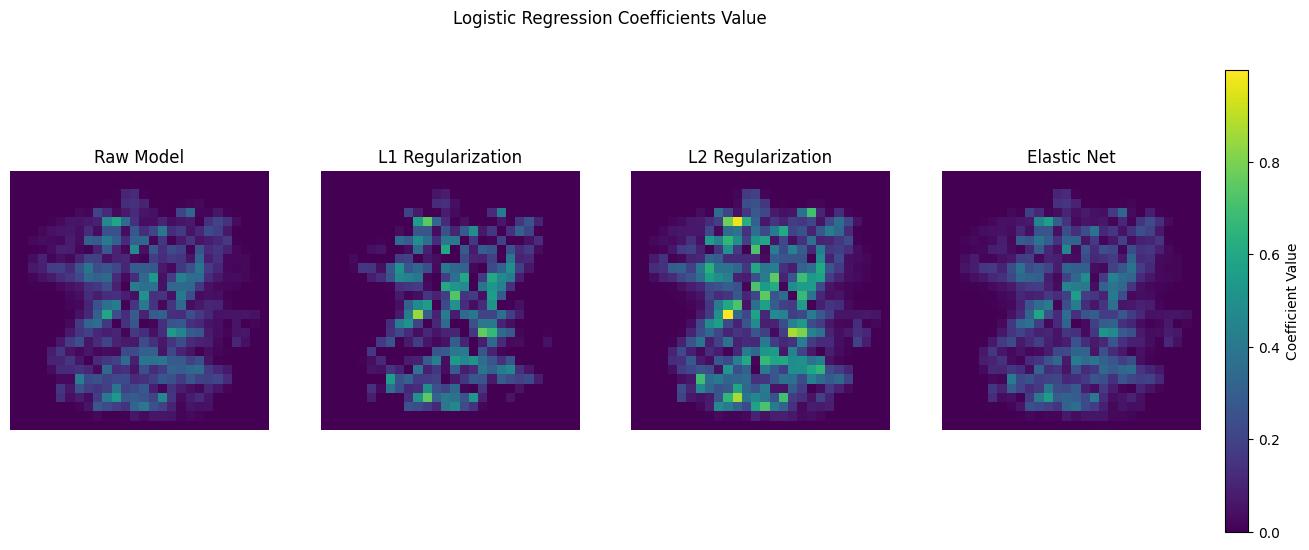

In [977]:
vizualise_coefs(coefs, names)
plt.suptitle("Logistic Regression Coefficients Value")
plt.show()

This figure displays the absolute value of our Logistic Regression's coefficients for each regularization we retained. We first can observe that, logically, all the coefficients of pixels that are almost always black are equal to 0. For each of the regularizations, the "forms" drawed by important coefficients are still quite the same and we can distinguish the numbers present in the dataset, especially the 8 and the 7 on raw model, L2 regularized and logically on Elastic Net model.

One curious fact is that the L2 regularized model and the Elastic Net model (which is supposed to be purely L2 regularized) are not the same : indeed the coefficients of the L2 model seems to have a higher absolute value.

On this plot we can observe the effect of the different type of regularization :

- The L1 is leading to more sparisity in the coefficients, it could be useful if we want to select important features (to reduce computation time for example).

- The L2 regularization has higher significative coefficients than the raw model, also all the black pixel's coefficients are even lower than those of the L1 regularized model. It can be explained by the fact that in this dataset almost all pairs of significative pixels have a high intercovariance (see Annex below, from TP1), and the L2 regularization has for effect to to homogenise coefficents among groups of highly correlated pixels.
    
    Basically it means that a point of the space (subspace of $\mathbb{R}^{784}$) minimizing the log likelihood of the raw logistic regression is closer to the origin of $\mathbb{R}^{784}$ when all the coefficients of black pixels are very close to 0 and when all the significant coefficients are absolutely higher, which is good news since this regularization improves (a bit) our model's performance and sharpen the explainability of our linear model.

- The coefficients of the Elastic Net model seems to represent an intermediate between the coefficients of the raw model and of the L2 regularized model. We can explain the differences with the L2 regularized model by the difference in the solver ('saga' instead of 'lbfgs').


In [1006]:
logregd_best = logregd11
best_models_d.append(logregd_best)
perfs_d.loc['Logistic Regression'] = accuracy_score(Y_test_d, Y_te_d_reglog11)
perfs_d

LDA                    0.959
Logistic Regression    0.973
dtype: float64

#### [Annex] Intercovariance of Pixels in Digits Data

##### [Function] Display Covariance Matrix

In [979]:
## Define a function to plot covariance matrices as an image :
def display_cov(cov_matrix, data_title) :
    plt.imshow(cov_matrix)
    plt.title("Covariance Matrix of " + data_title)
    plt.colorbar()

##### End [Function]

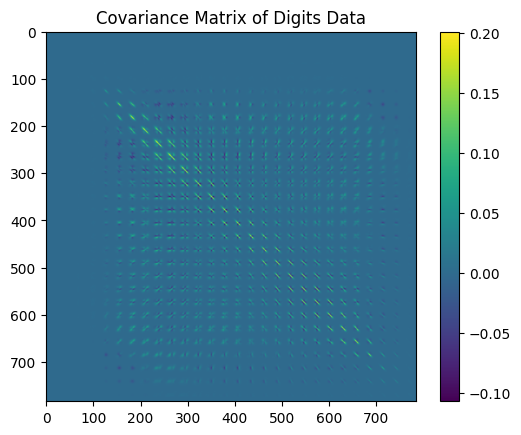

In [980]:
cov_digits = np.cov(X_train_d.T)

plt.figure()
display_cov(cov_digits, "Digits Data")
plt.show()

The data at the origin of this covariance matrix is a flattened version of the 28*28 images. From this image we can observe that border pixels are all uncorrelated and that the correlated pixels are concentrated at the center of the image. We can observe that the absolute value of these center pixels on the x axis is progressively increases as y increases and we get at the center of the images then proceeds to diminish until it gets to a constant value of 0.

Each apparent sub-matrix corresponds to the covariance of a line with another (characterized by their position on the y axis). Their form vary but represent a coherent evolution according to their position on the matrix. For example the pixels from the lines 4 to 13 (top of the image), seems to be strongly correlated.

- In the same line, pixels seems to have a strong covariance with their neighbors. It can be explained by the fact that each drawed number has a thickeness of a few pixels. It is especially the case at the top of the numbers, 1, 7, and 8 have a more or less large band at their top (in average it's large). Indeed we can observe this strong neighbor covariance for the top lines on the global covariance matrix.
 
- In different lines, position on the x axis seems to have a strong covariance with their symetric according to the middle point of the image.

We can also observe this symmetry on the global covariance matrix : as y increase the 'vector' drawed by the pixels with strong covariance progressively roatate : 

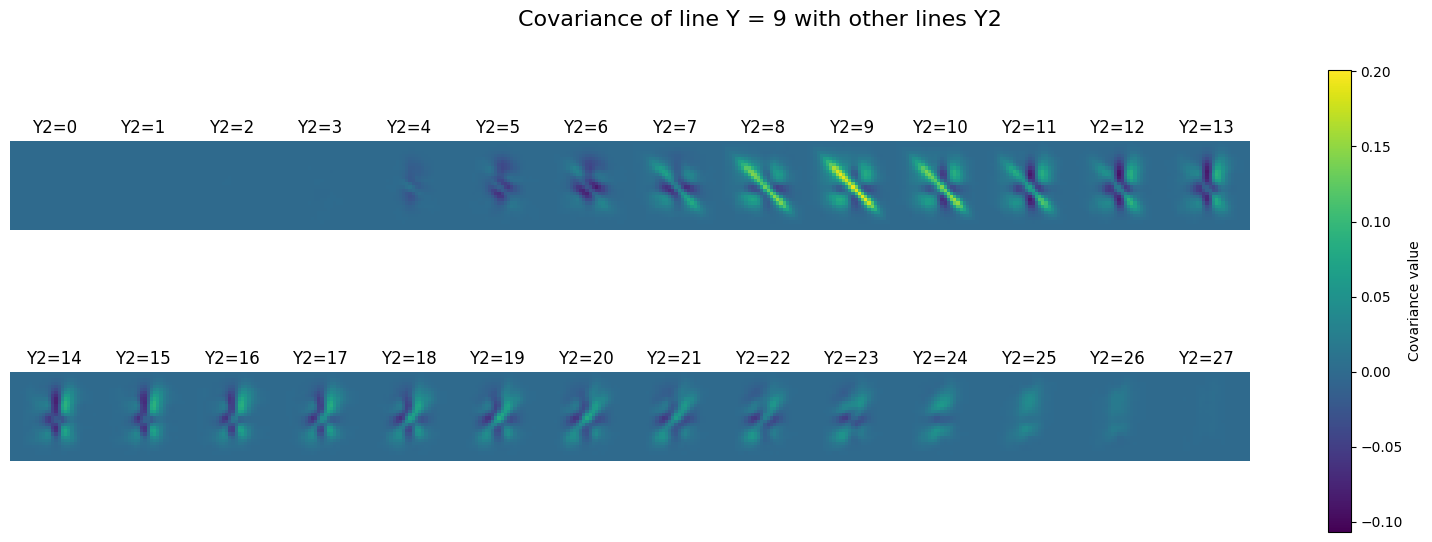

In [981]:
## For example if we look at the covariance of the line Y = 9 with all the other lines :

Y = 9
img_size = 28
n_features_digits = len(X_digits[0])

fig, axs = plt.subplots(2,14, figsize = (20, 6))

vmin = cov_digits.min()
vmax = cov_digits.max()

ims = []

for i in range(n_features_digits//img_size):
    im = axs[i//14, i%14].imshow(cov_digits[img_size * Y : img_size * (Y+1), img_size * i : img_size * (i+1)], vmin = vmin, vmax = vmax)
    axs[i//14, i%14].axis('off')
    axs[i//14, i%14].set_title(f"Y2={i}")
    ims.append(im)

plt.subplots_adjust(wspace=0, hspace=0)
cbar = fig.colorbar(ims[0], ax=axs)
cbar.set_label("Covariance value")

fig.suptitle(f"Covariance of line Y = {Y} with other lines Y2", fontsize = 16)
plt.show()

This central symmetry can be explained by the form of the numbers 1, 7 and 8 : 8 is completely central symmetric, 1 is almost, 7 is not but contains more or less a diagonal. In average, these numbers admits approximatively a central symmetry.

### SVC

We'll try a RBF SVC and a linear SVC

In [982]:
from sklearn.svm import SVC

In [983]:
svcd0 = SVC(kernel = 'linear', random_state= 42)
svcd0.fit(X_train_d, Y_train_d)

svcd01 = SVC(kernel = 'rbf', random_state= 42)
svcd01.fit(X_train_d, Y_train_d)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [984]:
Y_tr_d_svcd0 = svcd0.predict(X_train_d)
Y_te_d_svcd0 = svcd0.predict(X_test_d)

Y_tr_d_svcd01 = svcd01.predict(X_train_d)
Y_te_d_svcd01 = svcd01.predict(X_test_d)

print("Linear SVC")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_svcd0))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_svcd0))

print("\n RBF SVC")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_svcd01))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_svcd01))

Linear SVC
 - Training Accuracy :  1.000
 - Test Accuracy :  0.973

 RBF SVC
 - Training Accuracy :  0.998
 - Test Accuracy :  0.986


As we could have guessed (by looking at the form of the numbers, especially 8), the RBF kernel is providing a better model on test data, despite less performant on training data. Let's keep this kernel and try to optimize the hyperparameters C (regularization) and gamma :

In [985]:
svc1 = SVC(kernel = 'rbf', random_state=42)

params = {
    'C' : np.logspace(0,3,10),
    'gamma' : np.logspace(-3,0,10)
}

clf_d5 = GridSearchCV(svc1, params, cv = 5, scoring = 'accuracy')
clf_d5.fit(X_train_d, Y_train_d)

,estimator,SVC(random_state=42)
,param_grid,"{'C': array([ 1. ...000. ]), 'gamma': array([0.001 ..., 1. ])}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(2.154434690031884)


In [986]:
clf_d5.best_params_

{'C': np.float64(2.154434690031884), 'gamma': np.float64(0.046415888336127774)}

In [987]:
svcd1 = clf_d5.best_estimator_


Y_tr_d_svcd1 = svcd1.predict(X_train_d)
Y_te_d_svcd1 = svcd1.predict(X_test_d)

print("Raw RBF SVC")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_svcd01))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_svcd01))

print("\nOptimized Model (C = ",svcd1.C,", gamma = ",svcd1.gamma,")")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_svcd1))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_svcd1))

Raw RBF SVC
 - Training Accuracy :  0.998
 - Test Accuracy :  0.986

Optimized Model (C =  2.154 , gamma =  0.046 )
 - Training Accuracy :  1.000
 - Test Accuracy :  0.984


In [1014]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline


As hyperparameters optimization don't provide a better result we keep the raw RBF SVC model :

In [1007]:
svcd_best = svcd01
best_models_d.append(svcd_best)
perfs_d.loc['SVC'] = accuracy_score(Y_test_d, svcd_best.predict(X_test_d))
perfs_d

LDA                    0.959
Logistic Regression    0.973
SVC                    0.986
dtype: float64

### MLP Classifier

In [989]:
from sklearn.neural_network import MLPClassifier

In [990]:
mlpd0 = MLPClassifier(random_state=42)
mlpd0.fit(X_train_d, Y_train_d)

,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,200
,shuffle,True
,random_state,42


In [991]:
Y_tr_d_mlpd0 = mlpd0.predict(X_train_d)
Y_te_d_mlpd0 = mlpd0.predict(X_test_d)

print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_mlpd0))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_mlpd0))

 - Training Accuracy :  1.000
 - Test Accuracy :  0.982


In [993]:
mlpd1 = MLPClassifier(random_state=42)

params = {
    'hidden_layer_sizes': [(64,), (128,), (128, 64), (256, 128)],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [0.001, 0.01],
    'activation': ['relu', 'tanh']
}

clf_d6 = GridSearchCV(mlpd1, params, cv = 5, scoring = 'accuracy')
clf_d6.fit(X_train_d, Y_train_d)

,estimator,MLPClassifier(random_state=42)
,param_grid,"{'activation': ['relu', 'tanh'], 'alpha': [1e-05, 0.0001, ...], 'hidden_layer_sizes': [(64,), (128,), ...], 'learning_rate_init': [0.001, 0.01]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,hidden_layer_sizes,"(256, ...)"


In [998]:
mlpd1 = clf_d6.best_estimator_

print("MLP Optimal Parameters :\n" , clf_d6.best_params_)

Y_tr_d_mlpd1 = mlpd1.predict(X_train_d)
Y_te_d_mlpd1 = mlpd1.predict(X_test_d)

print("Raw MLP Model")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_mlpd0))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_mlpd0))

print("Optimized MLP Model")
print(" - Training Accuracy : ", accuracy_score(Y_train_d, Y_tr_d_mlpd1))
print(" - Test Accuracy : ", accuracy_score(Y_test_d, Y_te_d_mlpd1))

MLP Optimal Parameters :
 {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.01}
Raw MLP Model
 - Training Accuracy :  1.000
 - Test Accuracy :  0.982
Optimized MLP Model
 - Training Accuracy :  1.000
 - Test Accuracy :  0.982


In [1929]:
print("Raw MLP Accuracy =", accuracy_score(Y_test_d, Y_te_d_mlpd0))
print("Optimized MLP Accuracy =", accuracy_score(Y_test_d, Y_te_d_mlpd1))

Raw MLP Accuracy = 0.982
Optimized MLP Accuracy = 0.982


Even if the optimized model has a slightly higher test accuracy than the raw model the difference it's negligible.

In [1008]:
mlpd_best = mlpd1
best_models_d.append(mlpd_best)
perfs_d.loc['MLP'] = accuracy_score(Y_test_d, mlpd_best.predict(X_test_d))
perfs_d

LDA                    0.959
Logistic Regression    0.973
SVC                    0.986
MLP                    0.982
dtype: float64

## Interpreting the Classifiers 

### Evaluate Model's Performance

According to the test accuracy the best model is the SVC. Let's look if this changes with other metrics.

In [1010]:
from sklearn.metrics import classification_report

models_names = perfs_d.index
for i in range(len(best_models_d)) :
    print(models_names[i])
    print(classification_report(Y_test_d, best_models_d[i].predict(X_test_d)))

LDA
              precision    recall  f1-score   support

           1       0.93      0.98      0.95      1000
           7       0.97      0.99      0.98      1000
           8       0.98      0.91      0.94      1000

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000

Logistic Regression
              precision    recall  f1-score   support

           1       0.97      0.98      0.97      1000
           7       0.97      0.99      0.98      1000
           8       0.98      0.95      0.96      1000

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000

SVC
              precision    recall  f1-score   support

           1       0.99      0.98      0.99      1000
           7       0.99      0.99      0.99      1000
           8       0.98      0.98      0.98    

Note that for linear models, the recall is better than the precision for the numbers 1 and 7 although it's the inverse for the number 8. For all classes the Logistic Regression has a higher f1-score than the LDA.

For non linear models, the SVC and MLP Classifiers have very similar scores. The difference in accuracy seems to be due to the identification of the number 1 : SVC has a higher f1-score on this class than the MLP. Also SVC has a higher precision on the number 7 and a higher recall on the number 8. Finally all the number are implied.

For further investigations we keep our best model : SVC

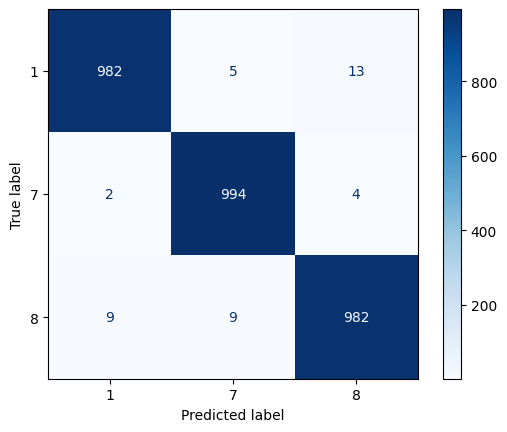

In [1025]:
best_model_d = svcd_best

Y_te_d_best = best_model_d.predict(X_test_d)
cm = confusion_matrix(Y_test_d, Y_te_d_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 7, 8])
disp.plot(cmap='Blues', colorbar=True)

The number 7 is the most identifiable by the model. The numbers 1 and 8 are sometimes confounded (22 times) and some 8 are identified as 7 by the model. The hardest classes to discriminate are the 1 and the 8.

In [1033]:
different_labels = [(Y_te_d_best[i] != Y_test_d[i]) for i in range(len(Y_test_d))]
idx_diff = [i for i, val in enumerate(different_labels) if val]
len(idx_diff)

42

Let's display these 42 misclassified numbers :

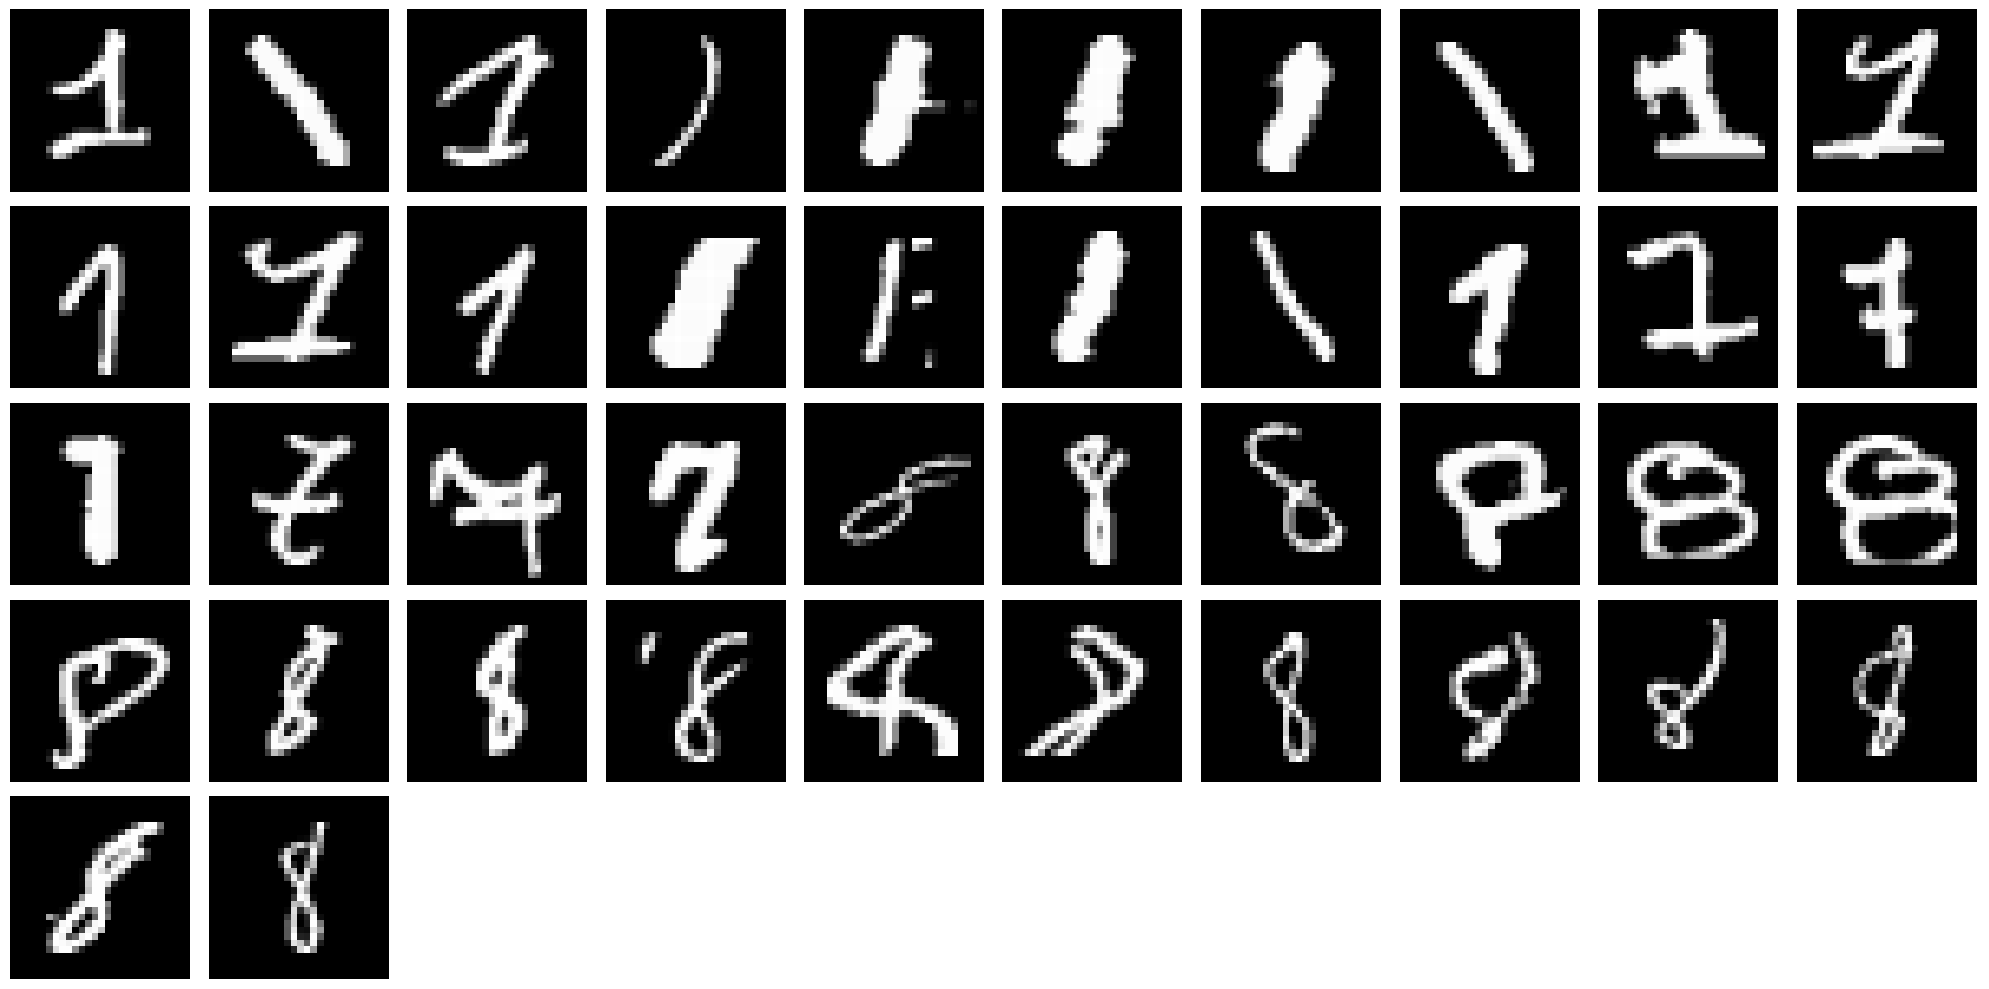

In [1053]:
display_images(X_test_d[idx_diff])

Indeed some of these numbers can be difficult to recognize, even for a human eye. It looks like the model confounds numbers having an inhabitual form, as very thick 1 can be confounded with 8, 1 with a large oblique stroke at its top can be confounded with 7 (even more if the 1 is leaning):

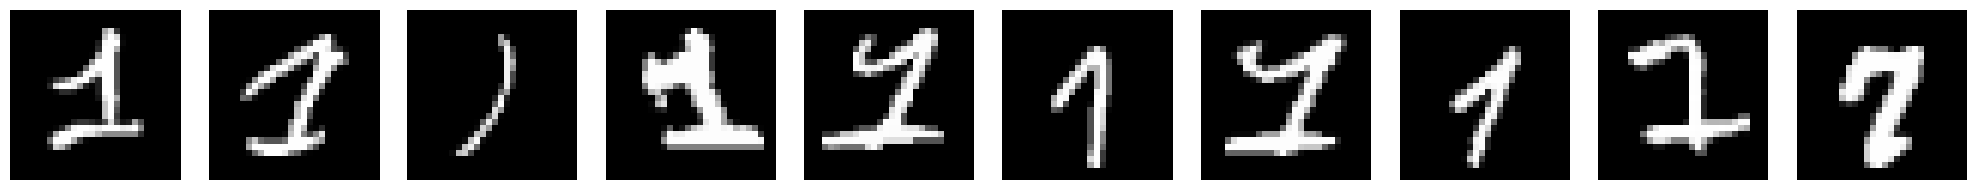

In [1039]:
display_images(X_test_d[[idx_diff[i] for i in [0,2, 3,8, 9,10, 11,12,  18, 23]]])

It's also the case for very thin eights which can be confounded with ones and sevens depending if it is leaning or not, or if one of its buckles if way bigger than the other :

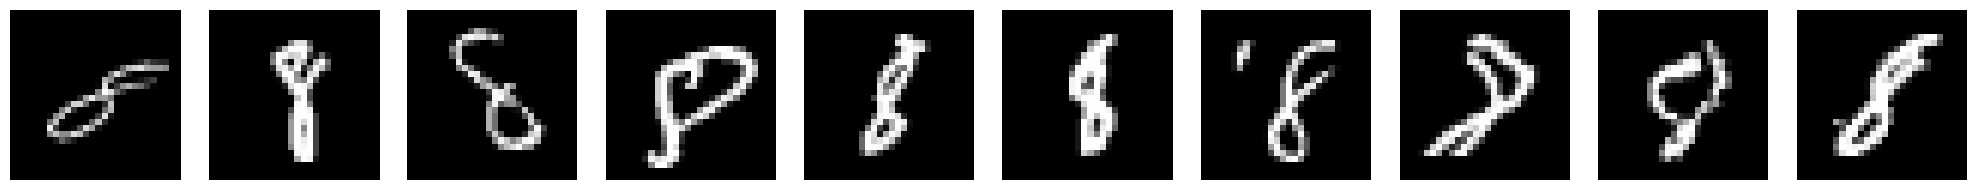

In [1046]:
display_images(X_test_d[[idx_diff[i] for i in [24,25, 26, 30,  31, 32, 33, 35, 37, 40]]])

Although we can explain some of these confusions, some are not directly interpretable, as the very big and round eight :

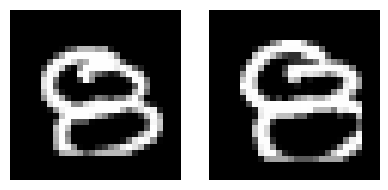

In [1052]:
display_images(X_test_d[[idx_diff[i] for i in [28, 29]]])

Now let's add noise to a successfully classified sample :

In [1062]:
idx_well_classified = [i for i, val in enumerate(different_labels) if not val]
idx_wc_bis = np.random.choice(idx_well_classified, 1000, replace = False)

In [1110]:
X_sc = X_test_d[idx_wc_bis]
Y_sc = Y_test_d[idx_wc_bis]

Let's try different amplitudes of uniform noise to have a scale. We'll distinguish the noises that mask completely the original number. 

In [1107]:
list_std = [0.01, 0.025, 0.05, 0.075, 0.1, 0.25, 0.5, 0.75, 1, 2]
list_noisy_imgs = []

img0 = X_sc[0].copy().reshape(28,28)
list_noisy_imgs = [np.random.randn(784).reshape(28,28)*var + img0 for var in list_std]

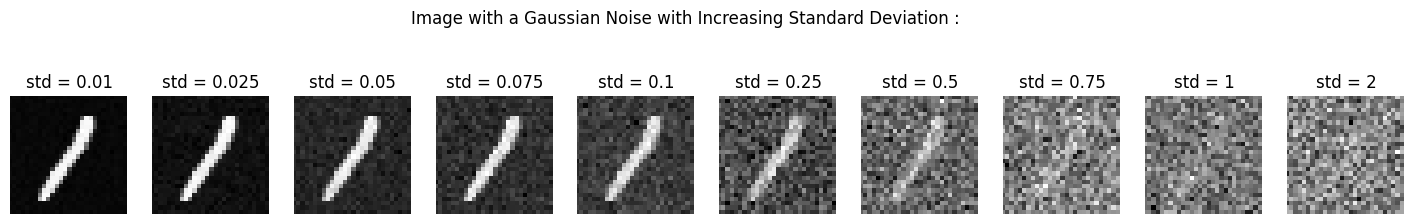

In [1108]:
n = len(list_std)
fig, axs = plt.subplots(1,n, figsize = (18,3))

for i in range(n) :
    ax = axs[i]
    ax.imshow(list_noisy_imgs[i], cmap = 'gray')
    ax.set_title(f"std = {list_std[i]}" )
    ax.axis('off')
    ax.set_xlim(0,28)
plt.suptitle("Image with a Gaussian Noise with Increasing Standard Deviation :")
plt.show()

Here the number 1 is clearly identifiable for std $\in [0.01,\, 0.5]$, vaguely identifiable for std = 0.075 and not identifiable anymore for std  $\in [1,\, 2]$ by human eye.
Let's see how the different noise affects the performances of our best model :

In [1119]:
np.random.seed(42)

noisy_samples = [[x + np.random.randn(784)*l for x in X_sc] for l in list_std]
perfs_noise = pd.Series()

for i in range(n):
    perfs_noise.loc[f"Std = {list_std[i]}"] = accuracy_score(Y_sc, best_model_d.predict(noisy_samples[i]))

perfs_noise

Std = 0.01     1.000
Std = 0.025    0.999
Std = 0.05     0.998
Std = 0.075    0.999
Std = 0.1      0.997
Std = 0.25     0.943
Std = 0.5      0.434
Std = 0.75     0.321
Std = 1        0.321
Std = 2        0.321
dtype: float64

We observe that our model is less perceptive as the human eye, as its accuracy decreases severely starting from std $=0.5$.

# Conclusion :

Next time I'll factorize my code earlier, the choice of the metric for the PIMA dataset was a subtle question. It was also difficult to find the good span of parameters to explore during grid search while limiting the number of combinations.

I really enjoyed the course, it allowed me to try new Machine Learning methods that I never explored while working on interesting datasets. I really enjoyed the medical application aspect of this practical wihich can lift up very interseting ethical and practical questions on the future of medecine.